# in silico ChIP at cell-type resolution

In [1]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
})
source('../insilico_chip/utils.R')

In [2]:
###################
## I/O
###################
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'

## All single-cells
io$RNA_sce = file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
io$ATAC_sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
io$meta = file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
#
io$motifmatcher <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")


In [3]:
opts = list()
opts$celltype.colors = c(
  "Epiblast" = "#635547",
  "Primitive_Streak" = "#DABE99",
  "Caudal_epiblast" = "#9e6762",
  "PGC" = "#FACB12",
  "Anterior_Primitive_Streak" = "#c19f70",
  "Notochord" = "#0F4A9C",
  "Def._endoderm" = "#F397C0",
  "Gut" = "#EF5A9D",
  "Nascent_mesoderm" = "#C594BF",
  "Mixed_mesoderm" = "#DFCDE4",
  "Intermediate_mesoderm" = "#139992",
  "Caudal_Mesoderm" = "#3F84AA",
  "Paraxial_mesoderm" = "#8DB5CE",
  "Somitic_mesoderm" = "#005579",
  "Pharyngeal_mesoderm" = "#C9EBFB",
  "Cardiomyocytes" = "#B51D8D",
  "Allantois" = "#532C8A",
  "ExE_mesoderm" = "#8870ad",
  "Mesenchyme" = "#cc7818",
  "Haematoendothelial_progenitors" = "#FBBE92",
  "Endothelium" = "#ff891c",
  "Blood_progenitors" = "#c9a997",
  "Blood_progenitors_1" = "#f9decf",
  "Blood_progenitors_2" = "#c9a997",
  "Erythroid" = "#EF4E22",
  "Erythroid1" = "#C72228",
  "Erythroid2" = "#f79083",
  "Erythroid3" = "#EF4E22",
  "NMP" = "#8EC792",
  "Neurectoderm" = "#65A83E",
  "Rostral_neurectoderm" = "#65A83E",
  "Caudal_neurectoderm" = "#354E23",
  "Neural_crest" = "#C3C388",
  "Forebrain_Midbrain_Hindbrain" = "#647a4f",
  "Spinal_cord" = "#CDE088",
  "Surface_ectoderm" = "#f7f79e",
  "Visceral_endoderm" = "#F6BFCB",
  "ExE_endoderm" = "#7F6874",
  "ExE_ectoderm" = "#989898",
  "Parietal_endoderm" = "#1A1A1A"
)

In [4]:
#######################
## Load RNA and ATAC 
#######################
# Load UMAP
umap = fread(file.path(io$basedir, 'results/rna_atac/mofa/pdf/batch_correction_False/umap.txt.gz'))
umap = umap[!grep('T_WT', cell)][!grep('T_KO', cell)]

meta_in = fread(io$meta)

# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(io$ATAC_sce)

# Make sure that samples are consistent
cells = intersect(colnames(rna.sce), umap$cell)
rna.sce <- rna.sce[,cells]
atac.sce <- atac.sce[,cells]

print(sprintf("Number of cells: %s",length(cells)))

[1] "Number of cells: 45707"


In [5]:
umap = umap[match(cells, cell)] %>% setnames(c('V1', 'V2'), c('UMAP1', 'UMAP2'))
meta_in = meta_in[match(cells, cell)]

meta_in = cbind(meta_in, umap[,cell:=NULL])

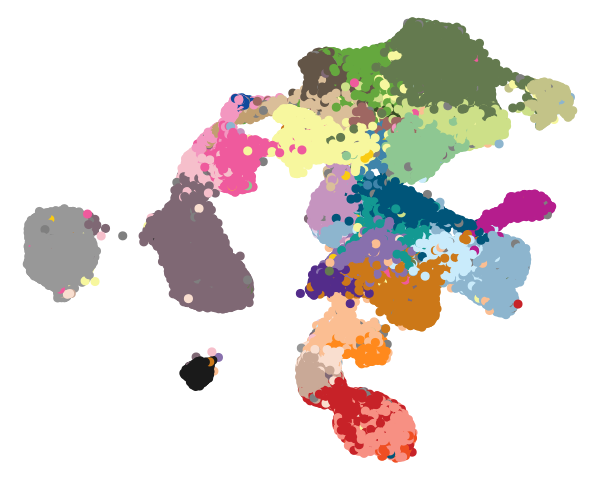

In [6]:
options(repr.plot.width=5, repr.plot.height=4)
ggplot(meta_in, aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void() +
    theme(legend.position='none')

In [7]:
#######################
## Load Motifs if wanted
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

In [8]:
# save single-cell matrices
rna.sce_bu = rna.sce
atac.sce_bu = atac.sce

In [9]:
rna.sce_bu = logNormCounts(rna.sce_bu)

In [10]:
TF = 'GATA1'

### Prepare ChIP & Peakset

In [11]:
library(GenomicRanges)
library(rtracklayer)

io$chip_dir.prefix <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/revisions/chip_files"
io$chip.files <- c(
  "CDX2" = file.path(io$chip_dir.prefix, "GSM2253707_Cdx2_wtEpiSCs_24h_rep1_mm10.bw"),
  "TAL1" = file.path(io$chip_dir.prefix, "GSM1692858_HP_Tal1.bw"),
  "GATA1" = file.path(io$chip_dir.prefix, "GSM1692851_HP_Gata1.bw"),
  "FOXA2" = file.path(io$chip_dir.prefix, "Foxa2.d5FS.bw"),
  "GATA4" = file.path(io$chip_dir.prefix, "GSM3223330_Gata4.d5FS.r1_m1.ucsc.bigWig"),
  "TBX5" = file.path(io$chip_dir.prefix, "Tbx5_WT_CP.bw")
)
#peak_metadata.gr = makeGRangesFromDataFrame(rowData(atac.sce))
peaks = data.frame(chr = str_split(rownames(atac.sce), ':') %>% map_chr(1),
          start = str_split(str_split(rownames(atac.sce), ':') %>% map_chr(2), '-') %>% map_chr(1),
          end = str_split(str_split(rownames(atac.sce), ':') %>% map_chr(2), '-') %>% map_chr(2)) 
peak_metadata.gr = makeGRangesFromDataFrame(peaks)
    
stopifnot(file.exists(io$chip.files))
TFs <- names(io$chip.files)

## calculate background ChIP signal 
chip_background.dt <- mclapply(TFs, function(i) {
  data.table(
    chip_anno = i,
    median = median(import.bw(BigWigFile(io$chip.files[[i]]))$score)
  )
}, mc.cores=10) %>% rbindlist

#### Run original chromVAR

In [12]:
bgdPeaks.se <- readRDS(io$background_peaks)
motifmatcher.se2 = motifmatcher.se
colnames(motifmatcher.se2) = str_split(colnames(motifmatcher.se2), '_') %>% map_chr(1)
chromvar_deviations_original.se = chromVAR_chip(atac.sce = atac.sce_bu, 
                                                   motifmatcher_chip.se = motifmatcher.se2,
                                                   assay = 'motifScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = FALSE, 
                                                   min_chip_score = 0,
                                                   min_number_peaks = 50,
                                                   TFs_filt = TF,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = 22)

[1] "Number of matches before filtering based on minimum ChIP-seq score: 22547537"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 22547537"
Running ChromVAR-ChIP-seq (ArchR implementation) 


as(<lgCMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "dMatrix") instead

2023-05-24 11:58:38 :  : Deviations for Annotation 1 of 1, 0.034 mins elapsed.



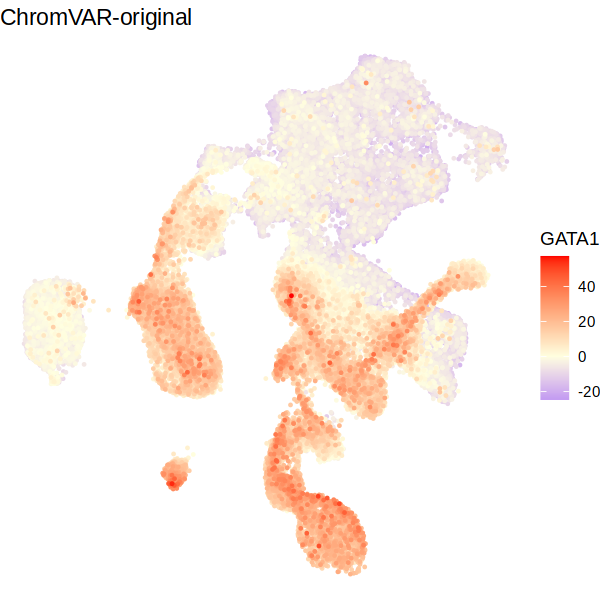

In [13]:
meta_in$original_chromvar = as.vector(assay(chromvar_deviations_original.se, 'z')[TF,])

p3 = ggplot(meta_in[order(original_chromvar)], aes(UMAP1, UMAP2, col=original_chromvar)) + 
    geom_point(size=0.3) +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-original') + 
    theme_void()

options(repr.plot.width=5, repr.plot.height=5)
p3

### ATAC Subsample function

In [89]:
ATAC_subsample = function(proportion){
    ###################
    ## Randomly subset scATAC-seq
    ################### 
    meta_atac = meta_in[sample(nrow(meta_in), nrow(meta_in)*proportion)]
    atac_subset.sce = atac.sce_bu[, meta_atac$cell]

    library(BiocParallel)
    BPPARAM = MulticoreParam(22)

    # pseudobulking per celltype
    print('Pseudobulking RNA & ATAC')
    a = Sys.time()
    rna.pb = aggregateAcrossCells(rna.sce_bu, id=meta_in$celltype, BPPARAM = BPPARAM)
    assayNames(atac_subset.sce) <- "counts"
    atac.pb = aggregateAcrossCells(atac_subset.sce, id=meta_atac$celltype, BPPARAM = BPPARAM)
    b = Sys.time()
    b-a


    rna.sce = rna.pb
    atac.sce = atac.pb
    print('ATAC statistics: ')
    print(summary(as.vector(assay(atac.sce, 'counts'))))

    rna.sce = rna.sce[,match(colnames(atac.sce), colnames(rna.sce))]
    summary(colnames(rna.sce) == colnames(atac.sce))

    assay(rna.sce,"logcounts") <- log(1e6*(sweep(assay(rna.sce),2,colSums(assay(rna.sce),na.rm=T),"/"))+1)
    assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)
    ###################
    ## Correlate TF-expr & Region-accessibility
    ###################  
    print('TF peak correlation')
    a = Sys.time()
    tf2peak_cor.se = cor_TF_acc(rna.sce, 
                              atac.sce, 
                              TFs_filt = c('CDX2', 'TAL1', 'GATA1', 'FOXA2', 'GATA4', 'TBX5'),  # c('SOX17', 'MYBL1') -> test runs
                              motifmatcher.se = motifmatcher.se, 
                              motif2gene.dt = motif2gene.dt,
                              correlation_method = "pearson", 
                              remove_motifs = c("T_789"),
                               cores = 22)
    b = Sys.time()
    b-a

    ######################################
    ## Create virtual chip-seq library 
    ######################################
    print('In-silico ChIP')

    a = Sys.time()
    motifmatcher_chip = silico_chip(atac.sce = atac.sce, 
                               tf2peak_cor.se = tf2peak_cor.se,
                               motifmatcher.se = motifmatcher.se,
                               motif2gene.dt = motif2gene.dt, 
                               min_number_peaks = 50,
                               TFs_filt = NULL, 
                               remove_motifs = c("T_789"),
                               cores = 22)

    motifmatcher_chip.se = motifmatcher_chip$motifmatcher_chip.se
    virtual_chip.dt = motifmatcher_chip$virtual_chip.dt
    b = Sys.time()
    b-a

    TFs = c('CDX2', 'FOXA2', 'GATA1', 'GATA4', 'TAL1', 'TBX5') # 
    chip_scores = as.data.table(as.matrix(assay(motifmatcher_chip.se[,TFs], 'VirtualChipScores')))

    chip_cutoff = suppressWarnings(mclapply(seq(0.01, 1, by=0.0001), function(x){ #
        tmp = chip_scores %>% melt() %>% setnames(c('TF', 'score')) %>% 
            .[score>=x] %>% 
            .[,N:=.N, by='TF'] %>% unique(by='TF')

        tmp2 = data.table(N = rep(x, nrow(tmp)),
                          TF = tmp$TF,
                          peaks = tmp$N)
        return(tmp2)
    }, mc.cores=12)) %>% rbindlist()

    options(repr.plot.width=5, repr.plot.height=5)
    p1 = ggplot(chip_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
        geom_line() + 
        geom_vline(xintercept=0.15, linetype='longdash') +
        scale_color_brewer(palette = 'Dark2') + 
        xlab('Minimum in silico binding score') + 
        ggtitle('Bart (whole atlas)') +
        theme_bw()

    print(p1)


    ######################################
    ## silico_chipseq_validation
    ######################################

    ## calculate signal 
    peak_metadata_ucsc.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ucsc.gr) <- 'UCSC'
    peak_metadata_ncbi.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ncbi.gr) <- 'NCBI'
    tf2seqstyle <- rep("UCSC",length(TFs)); names(tf2seqstyle) <- TFs
    tf2seqstyle["TBX5"] <- "NCBI"

    to.plot <- mclapply(TFs, function(i){
      # Load virtual ChIP-seq library
        virtual_chip_tmp = copy(virtual_chip.dt)[tf==i] %>% 
            setnames('peak', 'idx') %>% 
            .[,idx:=str_replace(idx,":","-")] %>%
            .[,chr:=strsplit(idx,"-") %>% map_chr(1)] %>%
            .[,start:=as.integer(strsplit(idx,"-") %>% map_chr(2))] %>%
            .[,end:=as.integer(strsplit(idx,"-") %>% map_chr(3))] %>%
            .[,idx:=str_replace(idx,"-",":")] %>% 
            setkey(chr,start,end)

        # Load ground truth ChIP-seq data
        if (tf2seqstyle[[i]]=="UCSC") {
            tmp <- peak_metadata_ucsc.gr
        } else if (tf2seqstyle[[i]]=="NCBI") {
            tmp <- peak_metadata_ncbi.gr
        }

        chip.dt <- import.bw(BigWigFile(io$chip.files[[i]]), selection = tmp) %>% as.data.table %>%
            .[,c(1,2,3,6)] %>% setnames(c("chr", "start", "end","value")) %>%
            .[,chr:=as.character(chr)] %>%
            .[,chr:=ifelse(grepl("chr",chr),chr,paste0("chr",chr))] %>%
          setkey(chr,start,end)

          # overlap ATAC peaks with ChIP-seq signal and quantify ChIP signal
        to.plot =  virtual_chip_tmp[,c("idx","chr","start","end")] %>%
            foverlaps(chip.dt, nomatch=0) %>% 
            .[,.(value=sum(value)), b=c("idx")] %>%
            merge(virtual_chip_tmp[,c("idx","score","motif_score", "max_accessibility_score")]) %>%
            .[,chip_anno:=as.factor(i)] %>%
            return

    }, mc.cores=10) %>% rbindlist

    seq.ranges <- seq(0,1,by=0.10); names(seq.ranges) <- as.character(1:length(seq.ranges))

    foo <- to.plot %>%
      .[score>=0] %>% 
      merge(chip_background.dt,by="chip_anno") %>%
      .[,log_value:=log(value+1)] %>%
      .[,c("chip_anno","idx","log_value","motif_score","score", "max_accessibility_score")] %>%
      setnames("score","score_rna_atac")

    to.plot.compare_models <- foo %>%
      # Model 1: DNA
      # .[,score_dna:=minmax.normalisation(motif_score), by="chip_anno"] %>% 
      # Model 2: DNA + ATAC
      .[,score_dna_atac:=minmax.normalisation(max_accessibility_score * motif_score), by="chip_anno"] %>% .[,score_dna_atac:=score_dna_atac+0.001] %>%
      # Model 3: DNA + ATAC + RNA
      .[,score_rna_atac:=minmax.normalisation(score_rna_atac), by="chip_anno"] %>% .[,score_rna_atac:=score_rna_atac+0.001] %>%
      # Discretise values
      # .[,score_dna_group:=cut(abs(score_dna), breaks=seq.ranges)] %>% .[,score_dna_group:=seq.ranges[as.numeric(score_dna_group)]] %>%
      .[,score_dna_atac_group:=cut(abs(score_dna_atac), breaks=seq.ranges)] %>% .[,score_dna_atac_group:=seq.ranges[as.numeric(score_dna_atac_group)]] %>%
      .[,score_rna_atac_group:=cut(abs(score_rna_atac), breaks=seq.ranges)] %>% .[,score_rna_atac_group:=seq.ranges[as.numeric(score_rna_atac_group)]] %>%
      # Prepare for plotting
      melt(id.vars=c("chip_anno","idx","log_value"), measure.vars=c("score_dna_atac_group","score_rna_atac_group"), variable.name="model", value.name="predicted_value") %>%
      .[,N:=.N,by=c("model","chip_anno","predicted_value")] %>%
      .[,.(mean=mean(log_value,na.rm=T), sd=sd(log_value,na.rm=T), N=.N), by=c("model","chip_anno","predicted_value")] %>%
      # Filter settings with a small number of observations
      .[!is.na(mean) & N>=25]

    options(repr.plot.width=15, repr.plot.height=7)
    p2 = ggline(to.plot.compare_models, x="predicted_value", y="mean", color="model", plot_type="b") +
      facet_wrap(~chip_anno, scales="free_y") +
      # geom_errorbar(aes(ymin=log_value-sd, ymax=log_value-sd), width=.2,) +
      scale_color_brewer(palette="Dark2", labels = c("ATAC", "RNA + ATAC")) +
      # scale_color_discrete(labels = c("DNA", "DNA + ATAC", "DNA + ATAC + RNA")) +
      labs(y="Observed ChIP-seq signal", x="In silico binding score") +
      theme(
        strip.background = element_rect(colour="black", fill=NA),
        axis.text = element_text(size=rel(0.55)),
        axis.title = element_text(size=rel(0.8)),
        legend.title = element_blank(),
        # legend.position = c(.26,.87)
        # legend.position = c(.06,.94)
        legend.position = "top"
      )

    print(p2)
    
    ######################################
    ## ChromVAR - ChIP-seq
    ######################################
    a = Sys.time()
    # load background peak set
    bgdPeaks.se <- readRDS(io$background_peaks)

    chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce_bu, 
                                                       motifmatcher_chip.se = motifmatcher_chip.se,
                                                       assay = 'VirtualChipScores',
                                                       background = bgdPeaks.se,
                                                       genome = NULL, # Only needed if background = NULL
                                                       positive_only = TRUE, 
                                                       min_chip_score = 0.25,
                                                       min_number_peaks = 50,
                                                       TFs_filt = NULL,
                                                       test = FALSE,
                                                       method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                       cores = 22)
    b = Sys.time()
    b-a

    ### Plot
    # get values
    meta_in$expr = as.vector(assay(rna.sce_bu, 'logcounts')[str_to_title(TF),])
    meta_in$chromvar = as.vector(assay(chromvar_deviations.se, 'z')[TF,])
    # remove outliers
    meta_in$chromvar = ifelse(meta_in$chromvar > quantile(meta_in$chromvar, 0.99), quantile(meta_in$chromvar, 0.99), meta_in$chromvar)

    p1 = ggplot(meta_in[order(expr)], aes(UMAP1, UMAP2, col=expr)) + 
        geom_point(size=0.3) +
        viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
        ggtitle(paste0(TF, ' - Expression')) + 
        theme_void()

    p2 = ggplot(meta_in[order(chromvar)], aes(UMAP1, UMAP2, col=chromvar)) + 
        geom_point(size=0.3) +
        scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
        ggtitle(paste0('ChromVAR-multiome, peaks: ', sum(as.vector(assay(motifmatcher_chip.se[,TF], 'VirtualChipScores')>0.25)))) + 
        theme_void()

    options(repr.plot.width=15, repr.plot.height=5)
    ggarrange(p1, p2, p3, ncol=3)
}

## No subsampeling

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


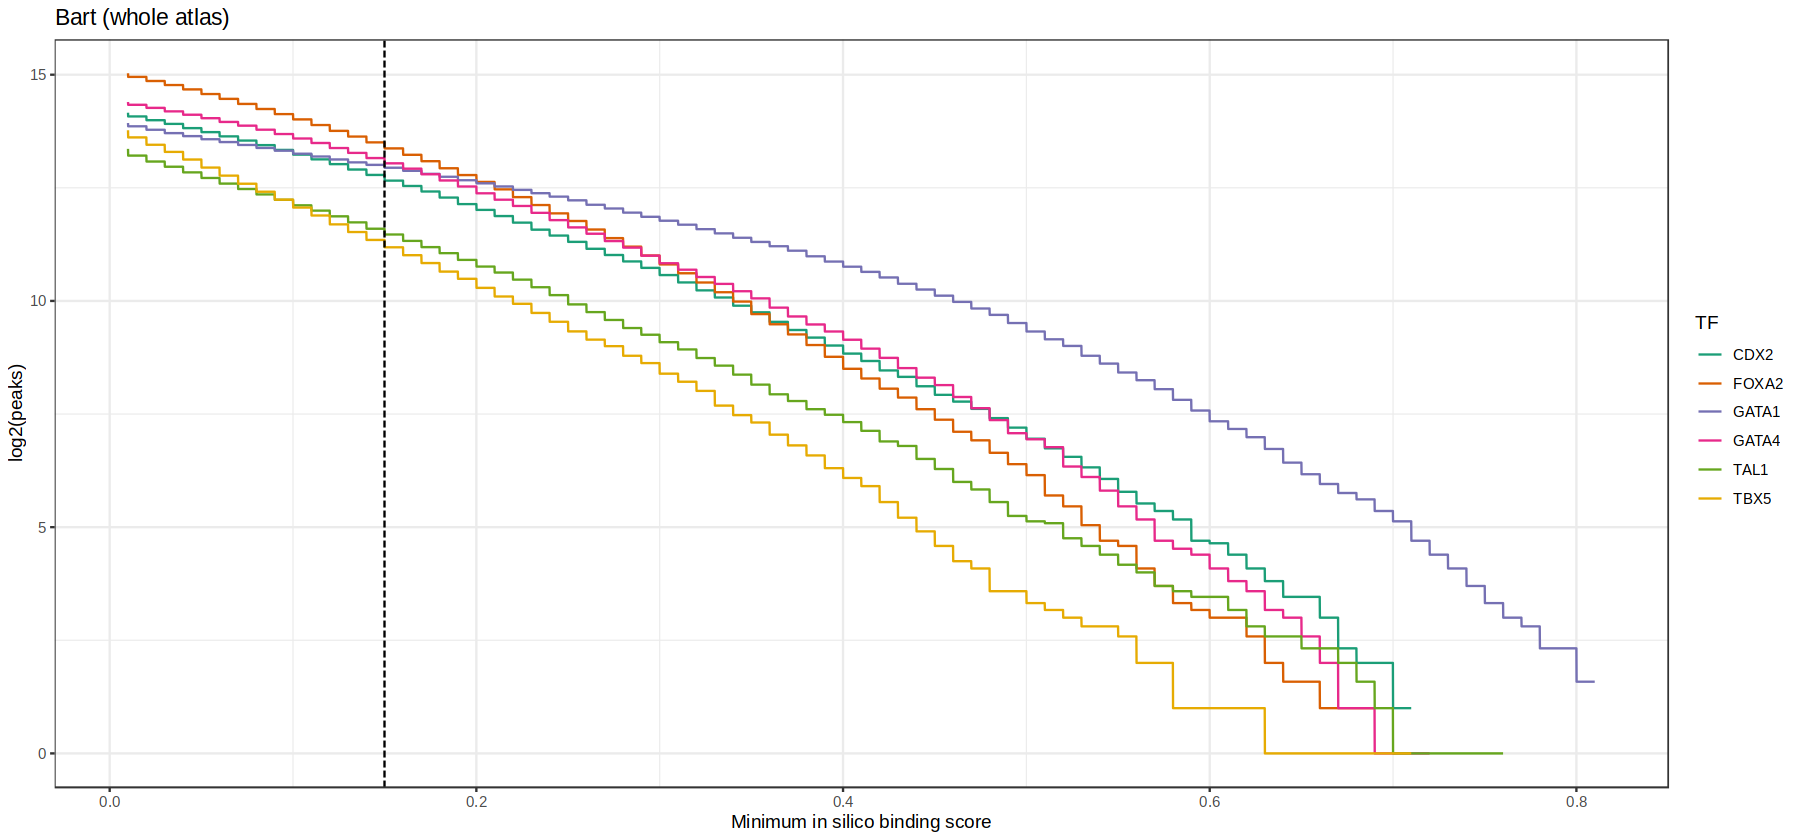

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 121072"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 121072"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 15566"
Running ChromVAR-ChIP-seq (ArchR implementation) 


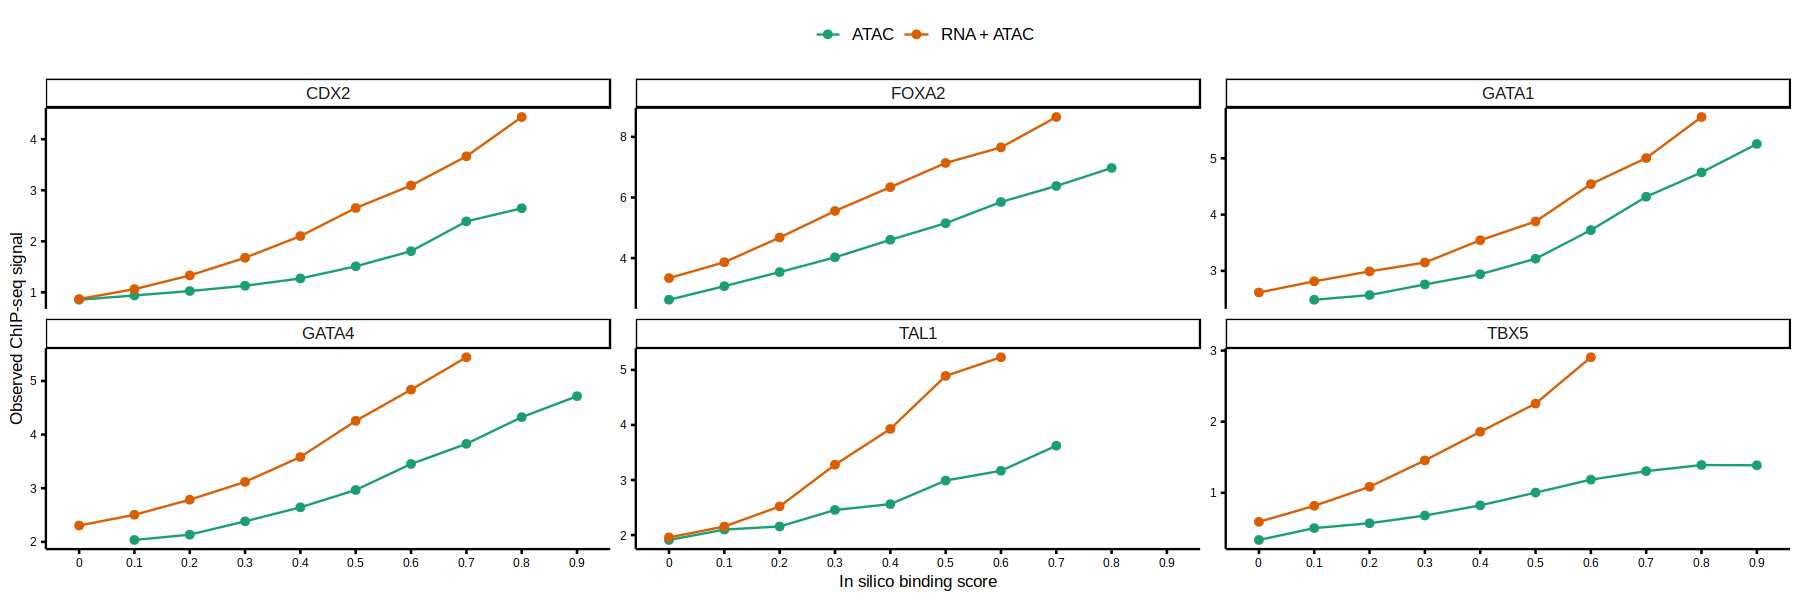

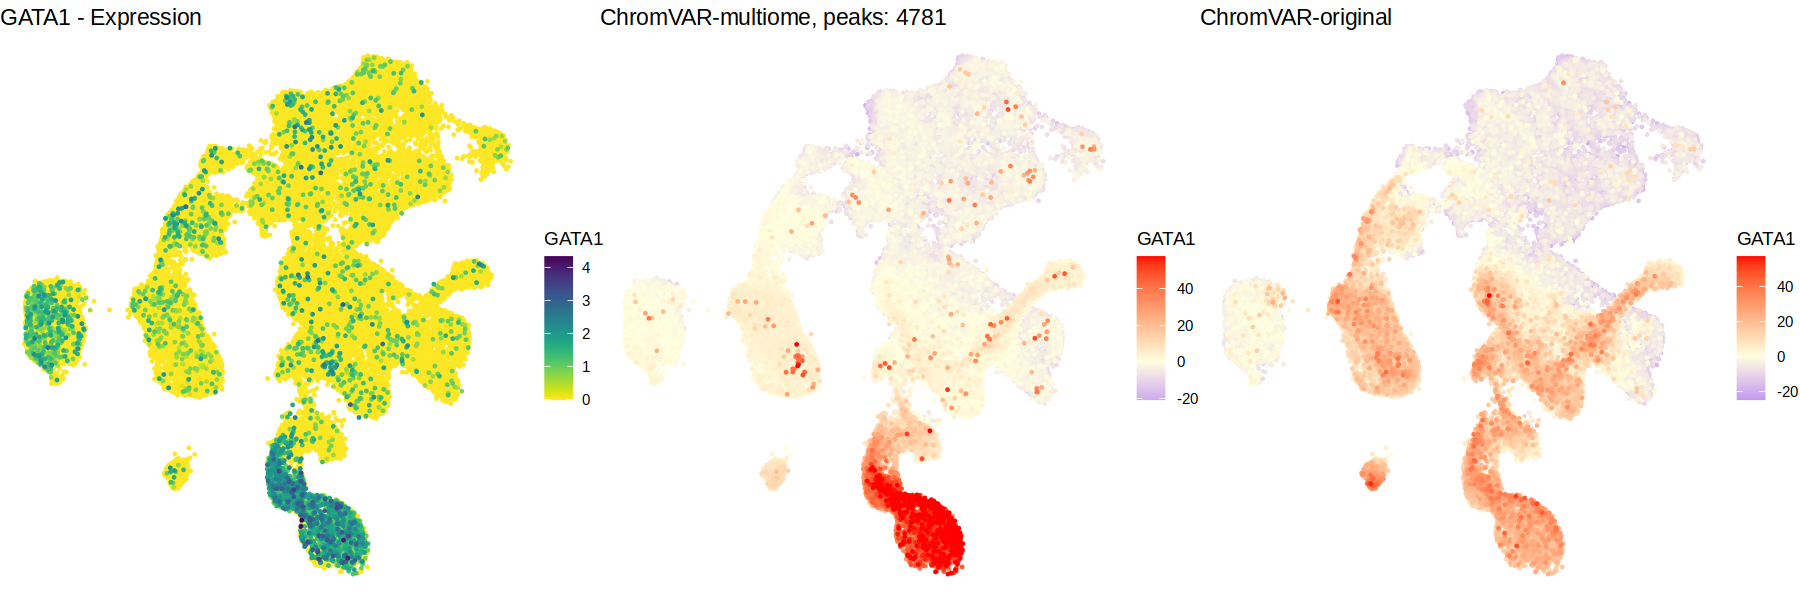

In [74]:
ATAC_subsample(1)

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


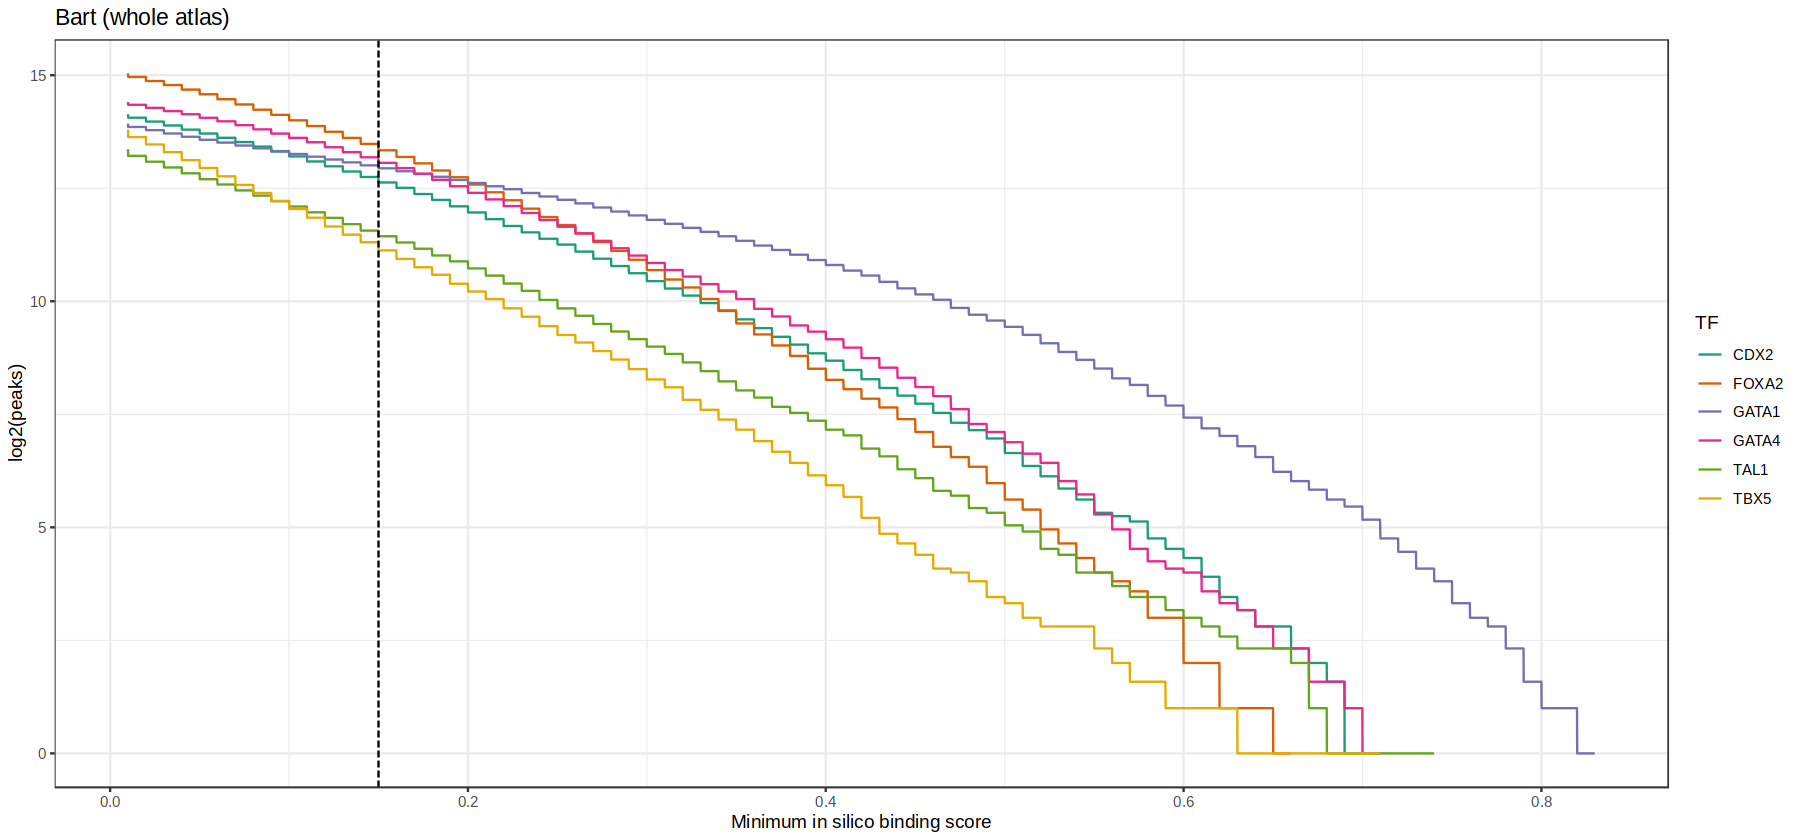

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 121617"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 121617"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 15331"
Running ChromVAR-ChIP-seq (ArchR implementation) 


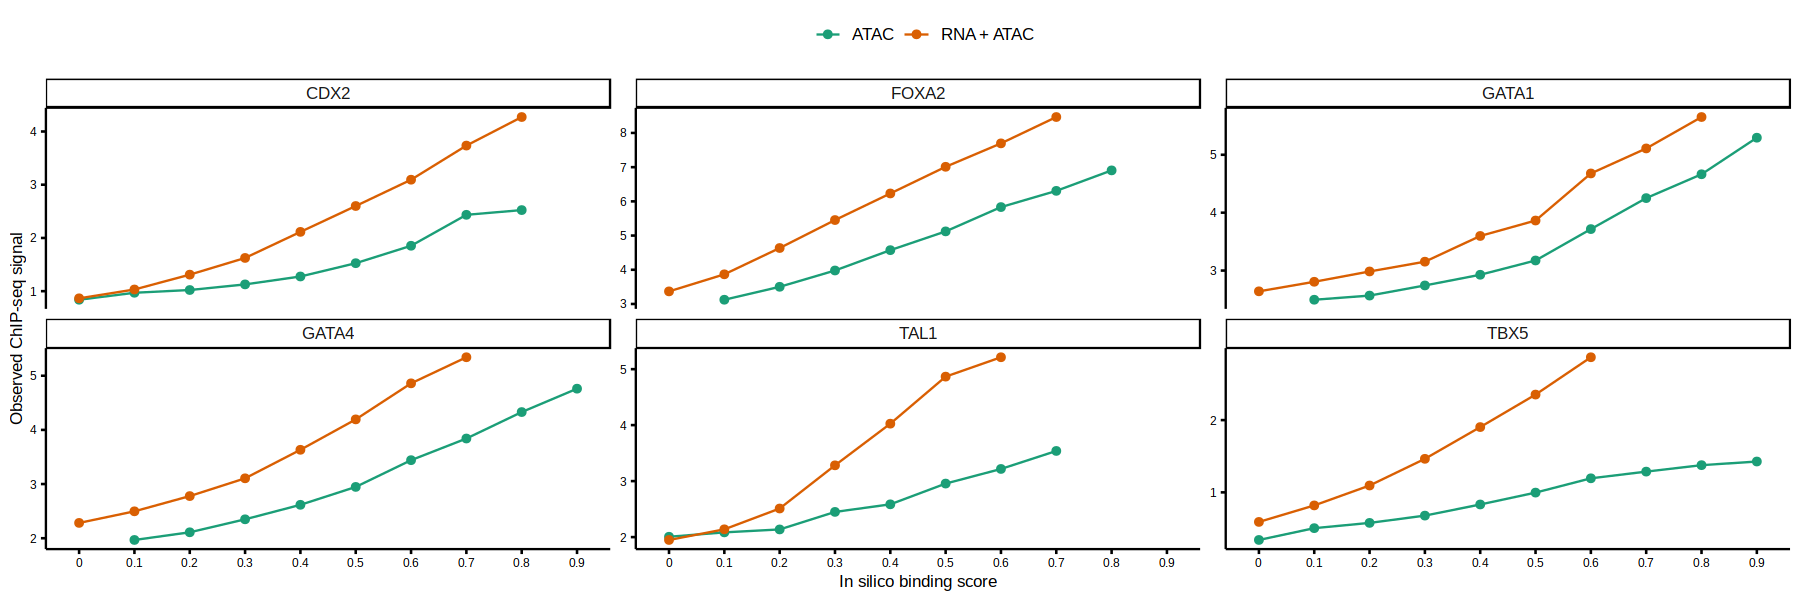

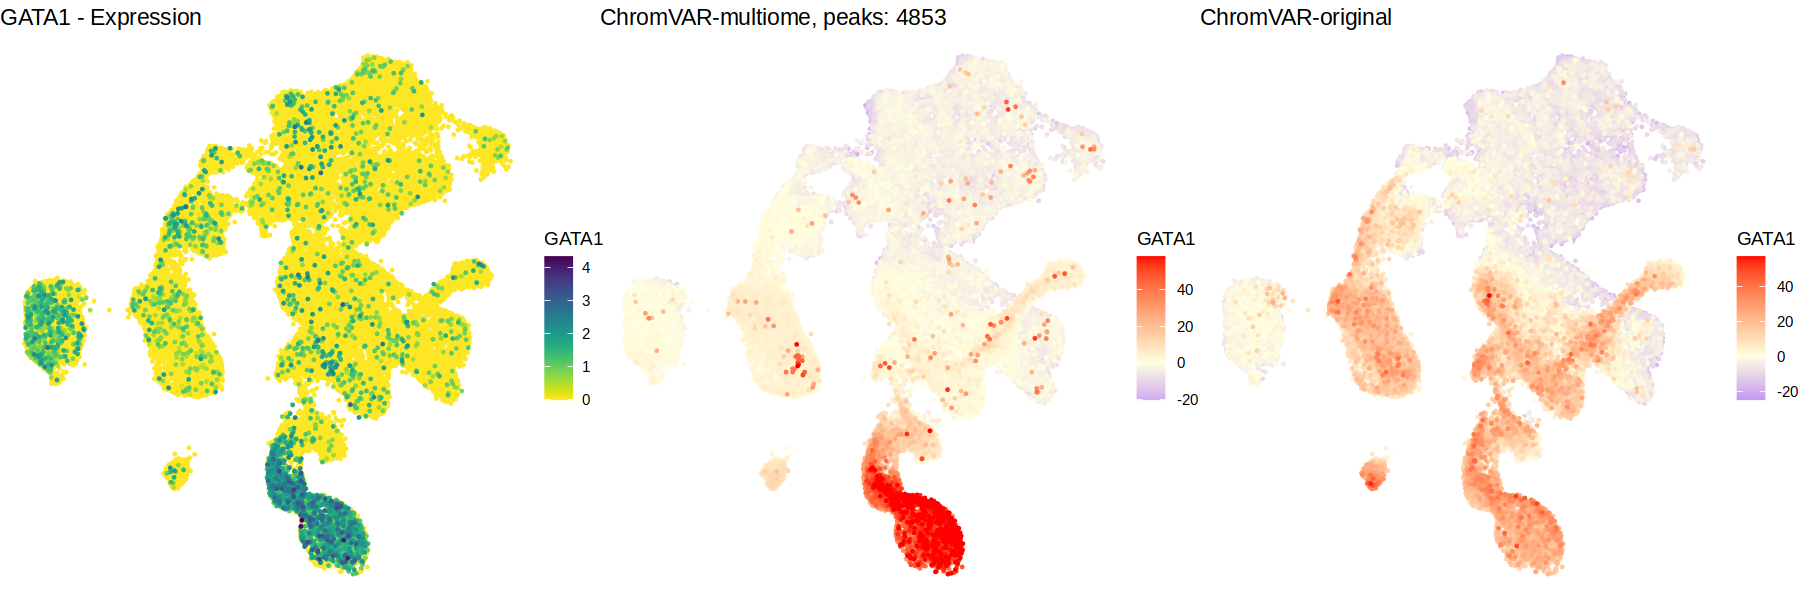

In [73]:
ATAC_subsample(0.75)

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


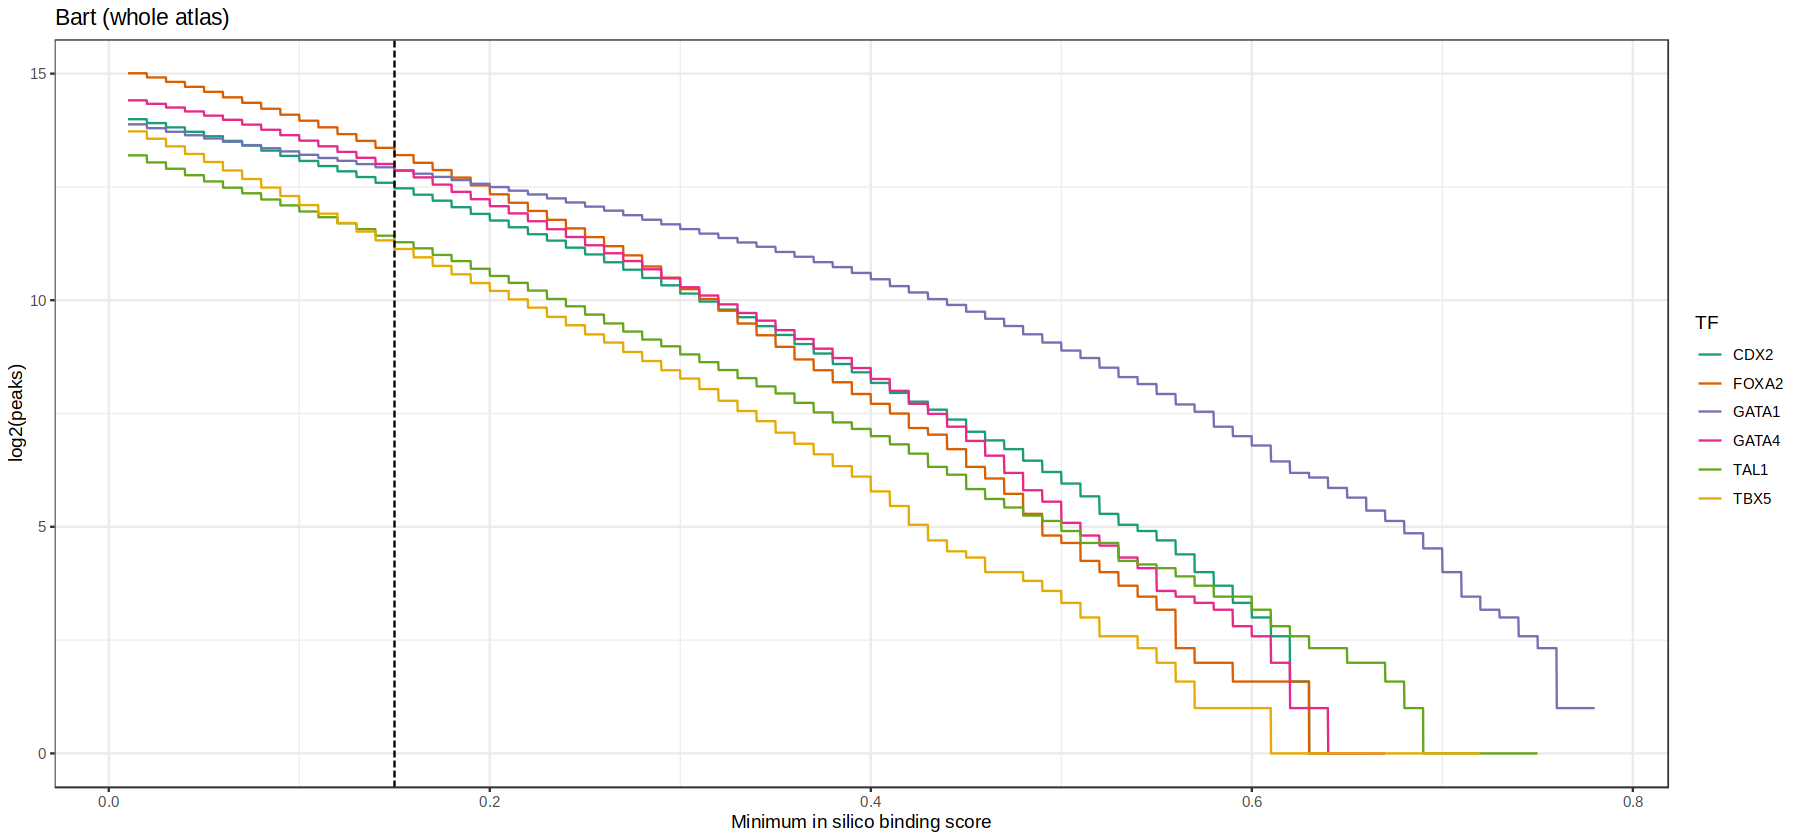

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 124850"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 124850"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 12839"
Running ChromVAR-ChIP-seq (ArchR implementation) 


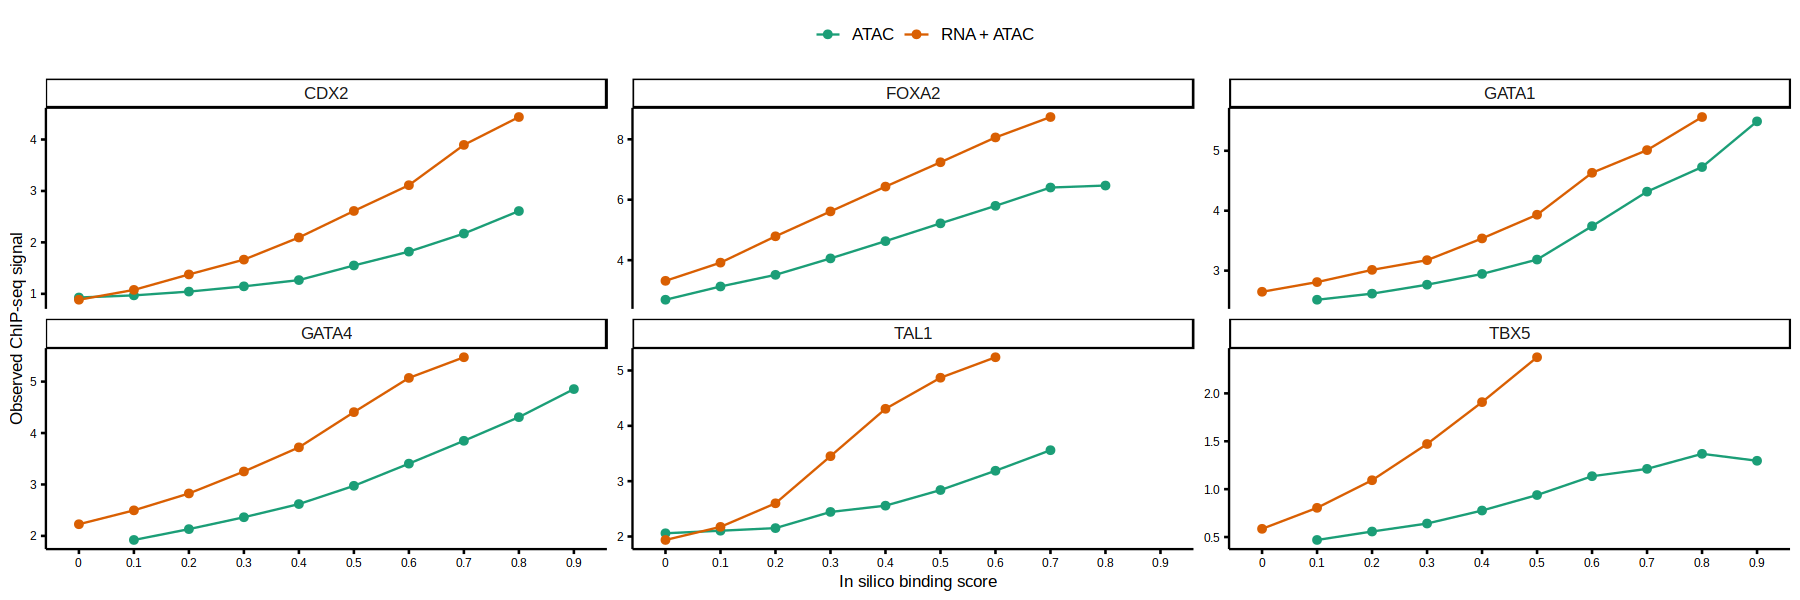

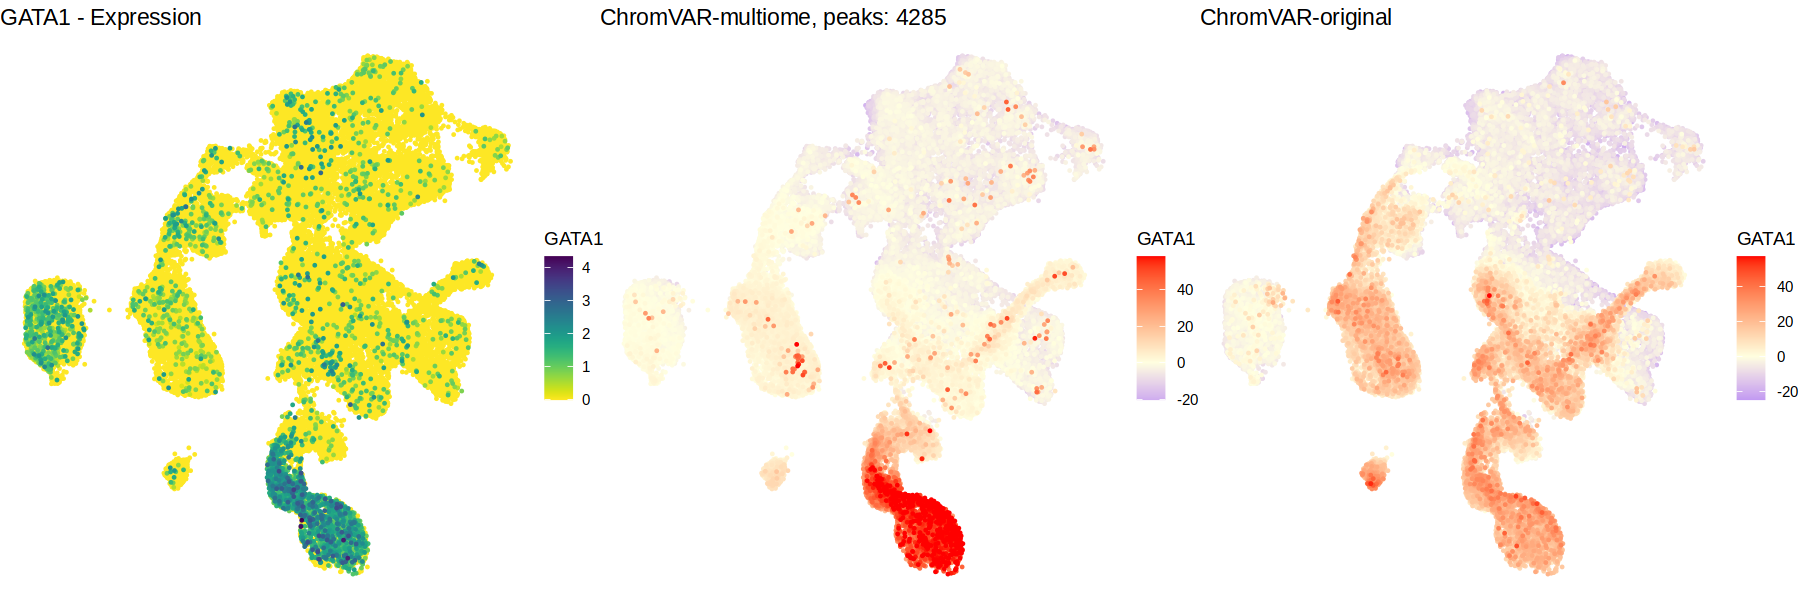

In [72]:
ATAC_subsample(0.5)


[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


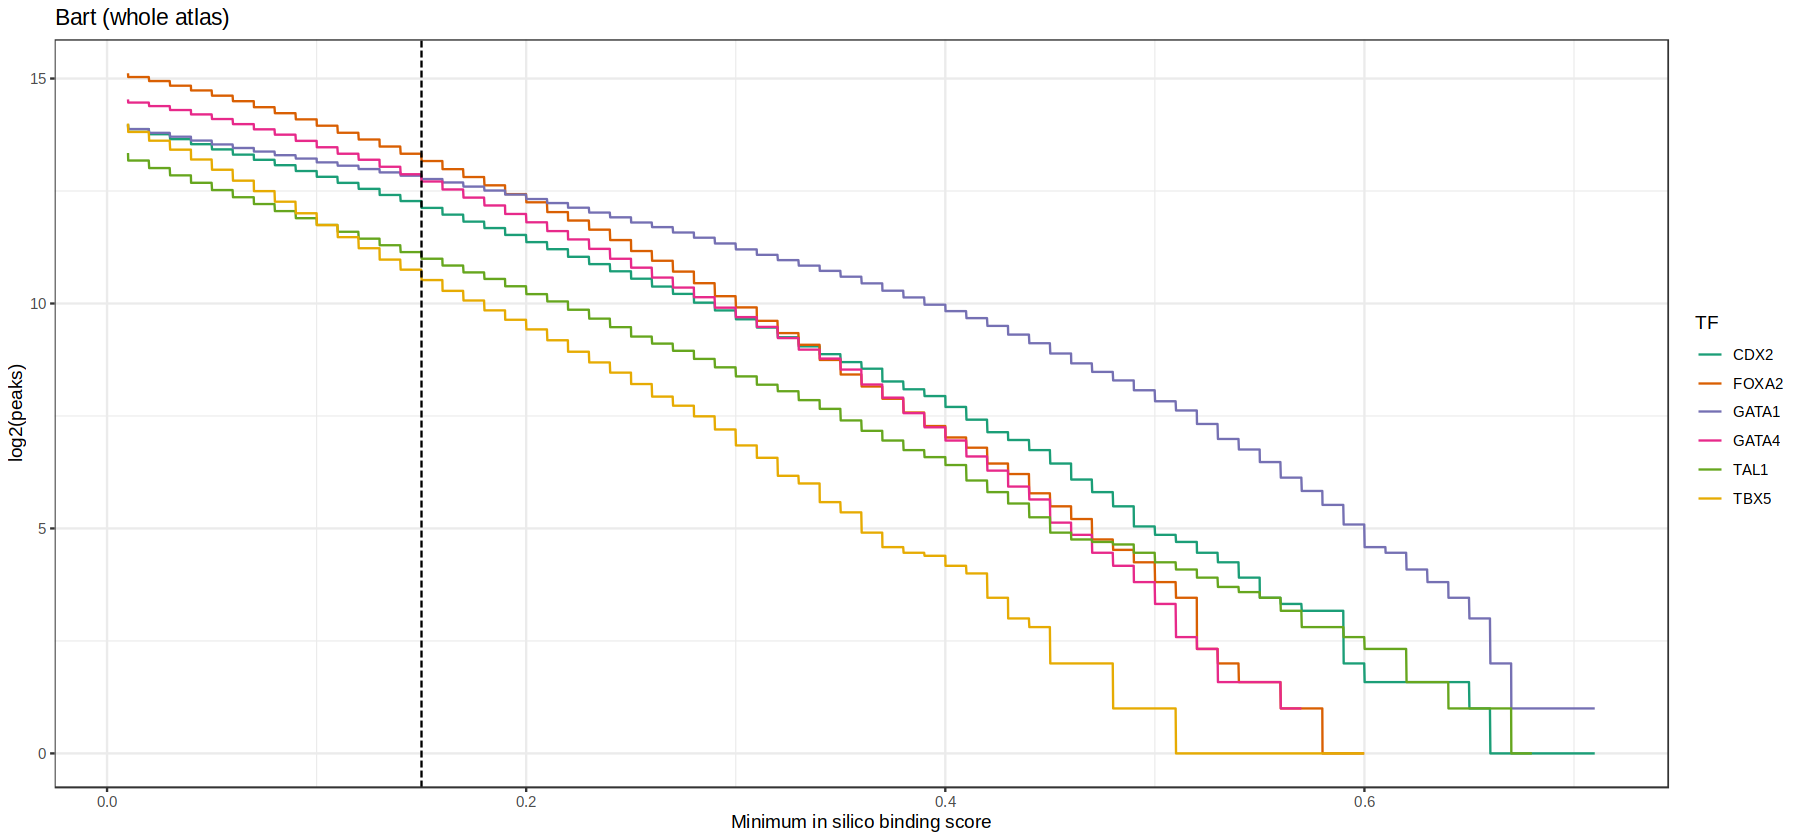

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 127445"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 127445"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 10053"
Running ChromVAR-ChIP-seq (ArchR implementation) 


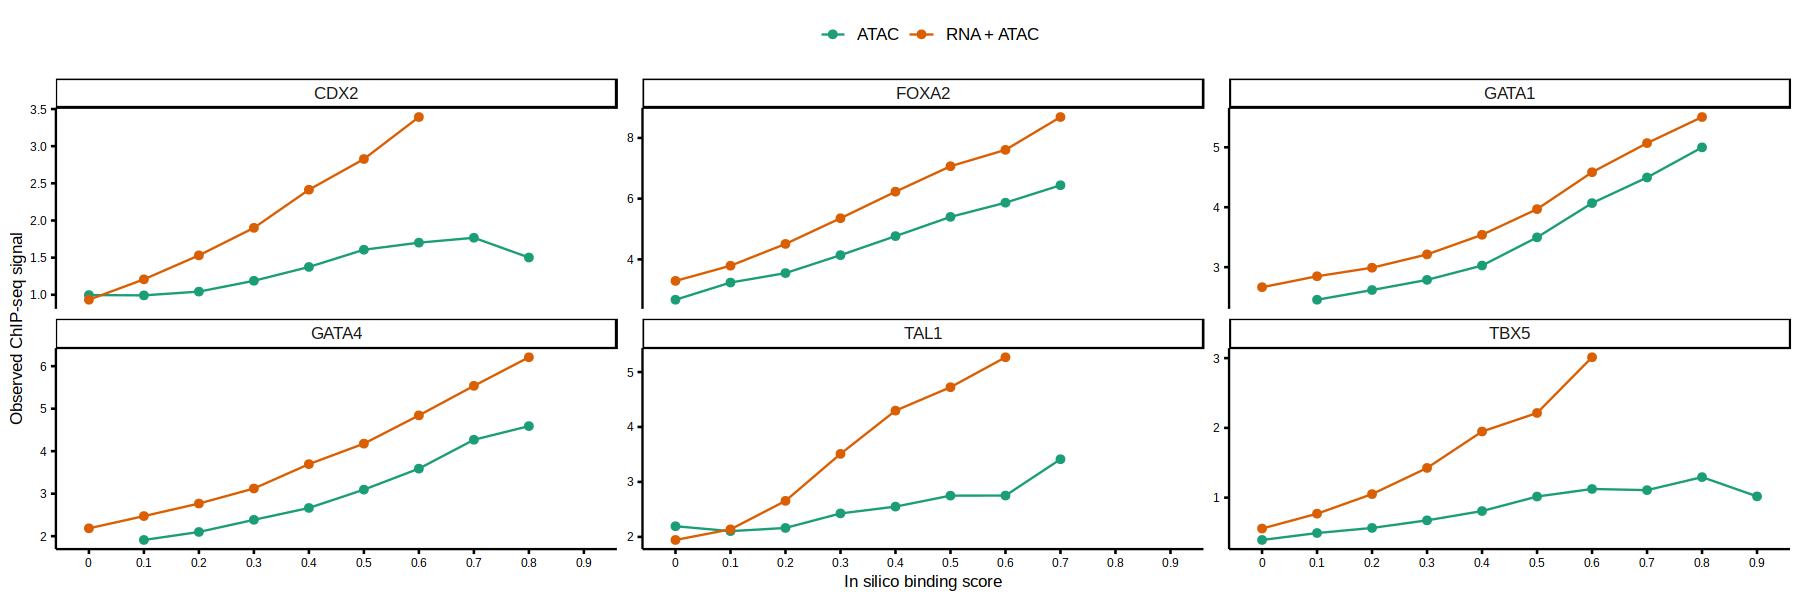

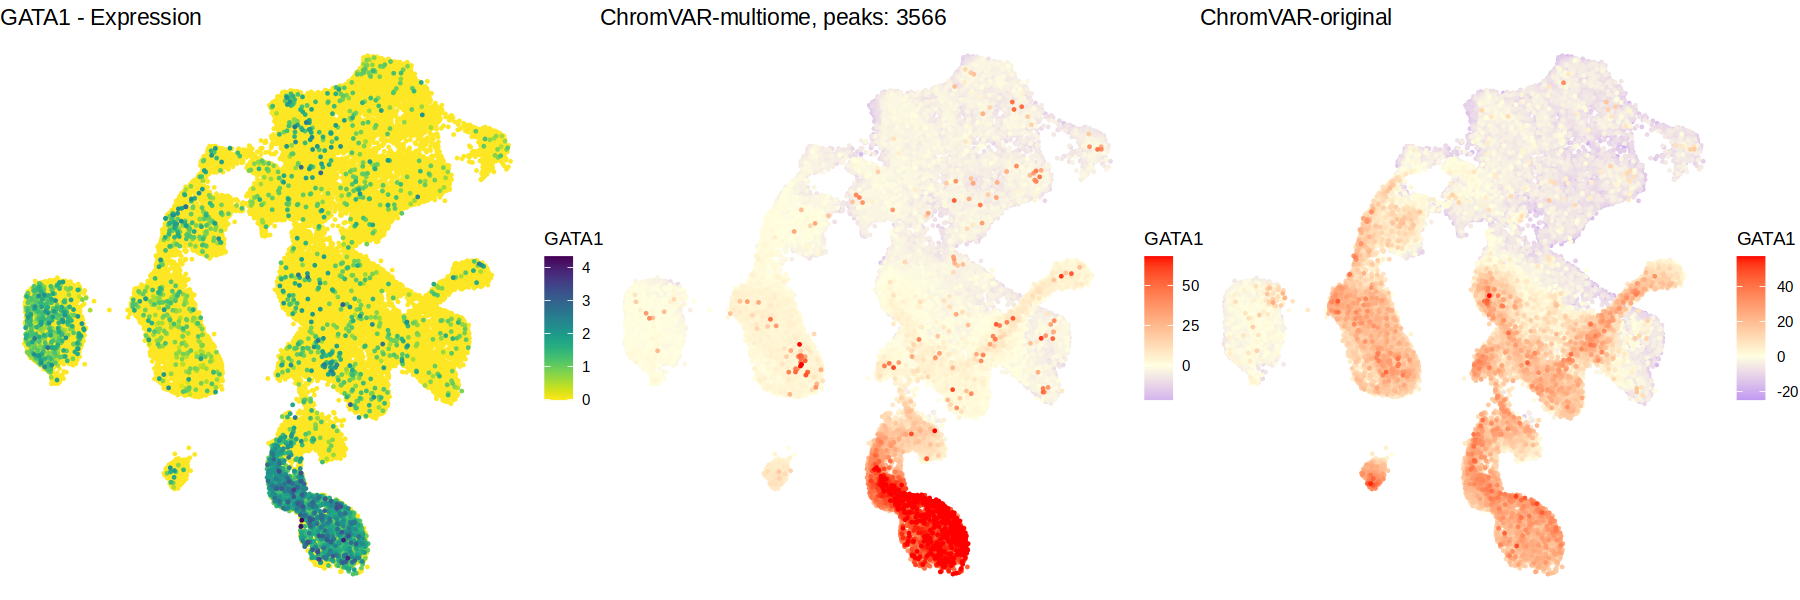

In [71]:
ATAC_subsample(0.25)

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


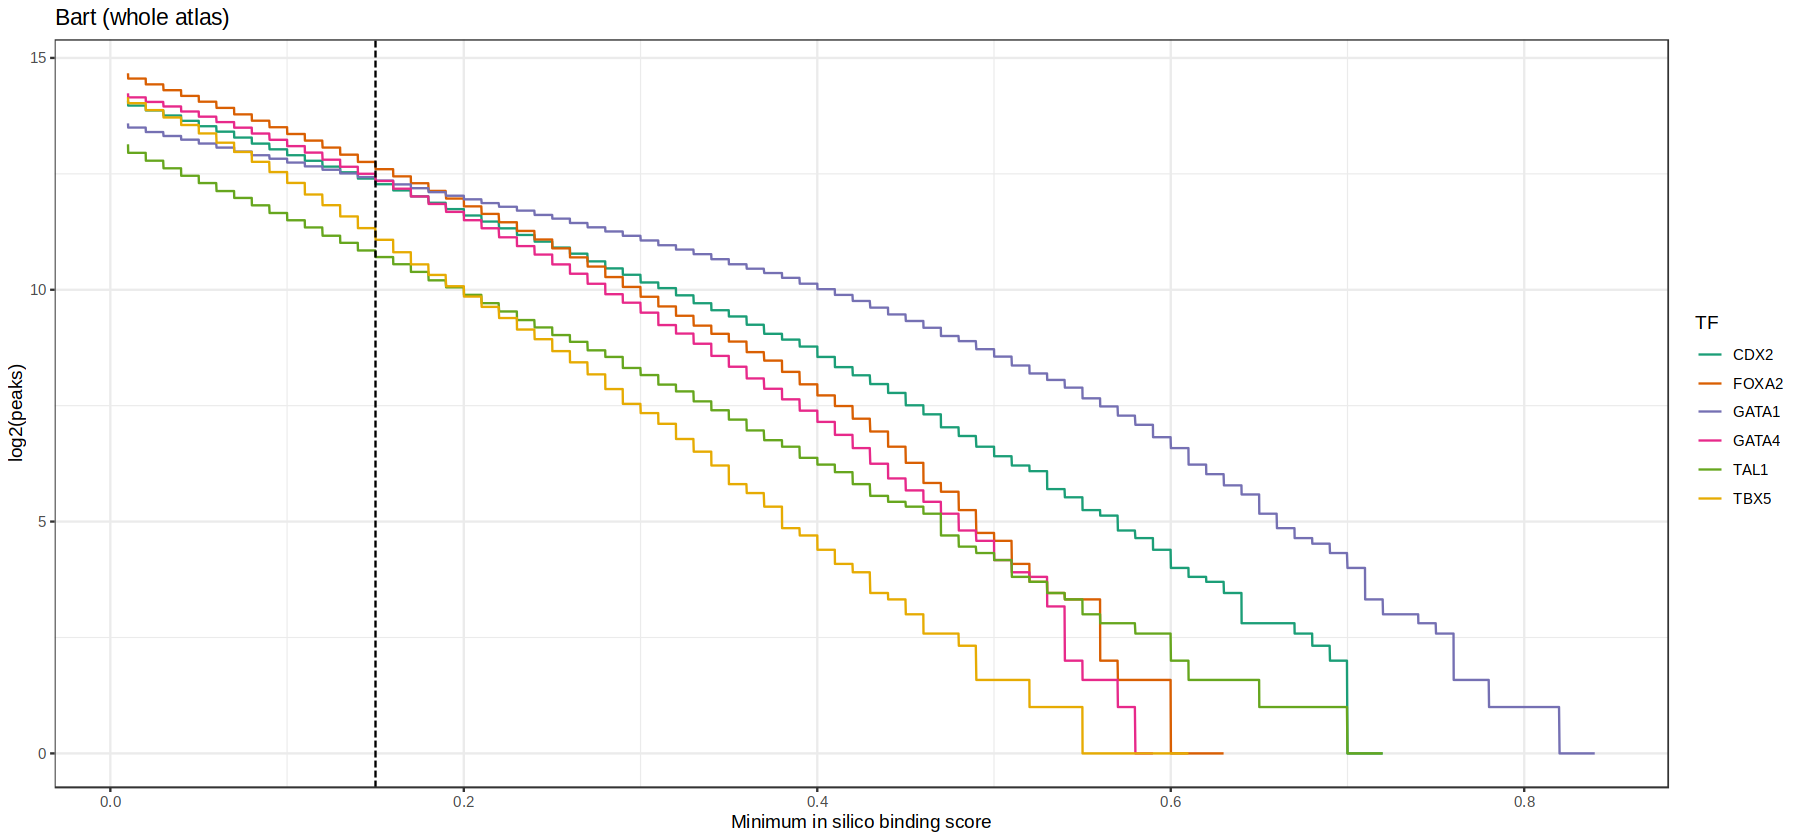

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 110849"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 110849"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 9215"
Running ChromVAR-ChIP-seq (ArchR implementation) 


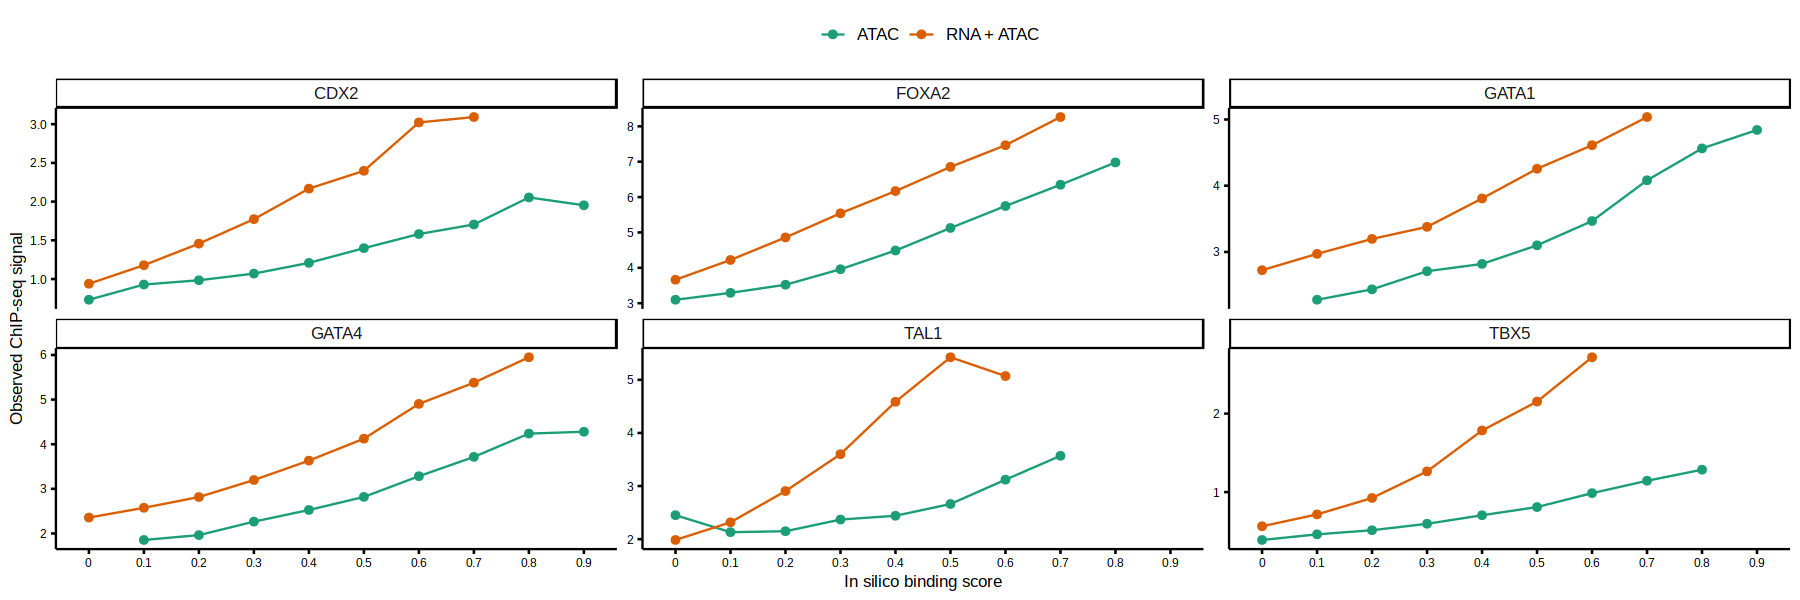

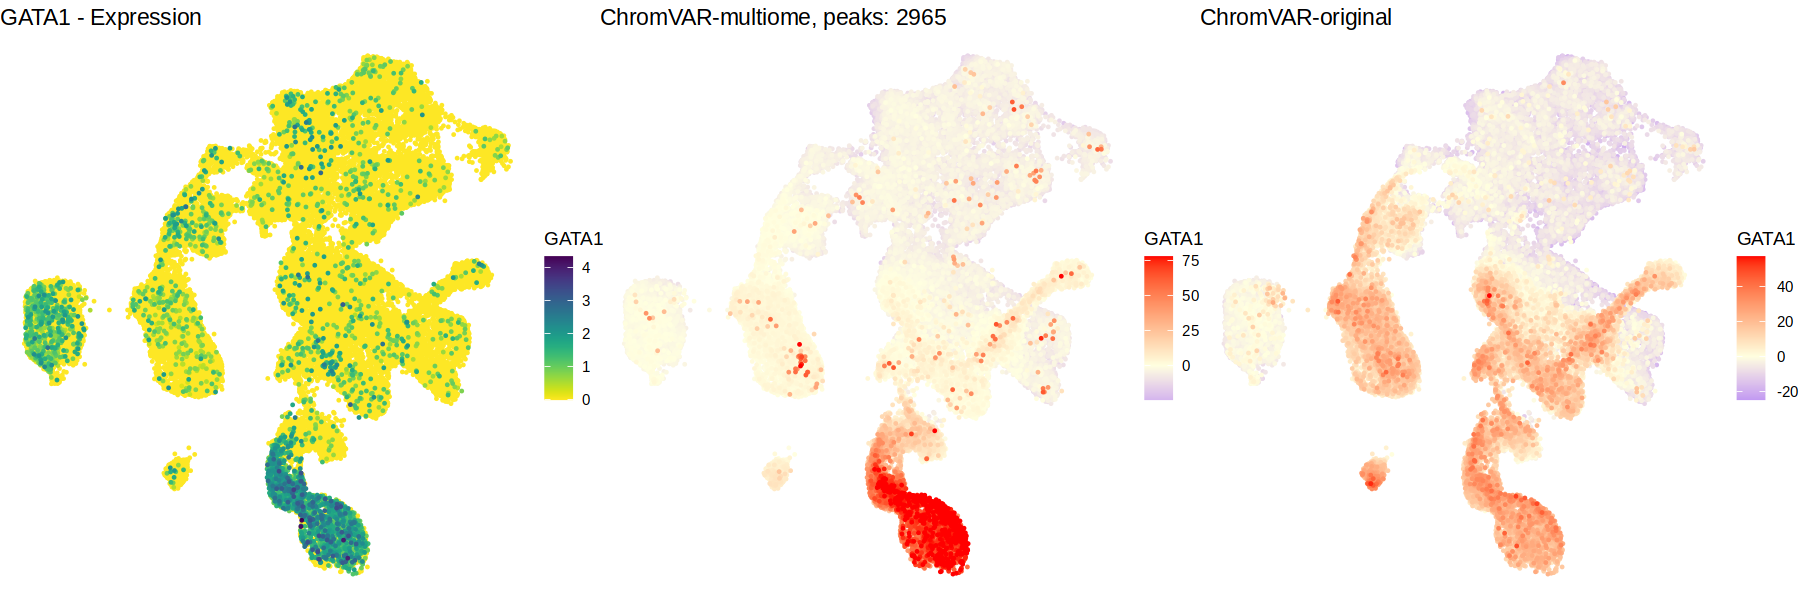

In [70]:
ATAC_subsample(0.05)

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


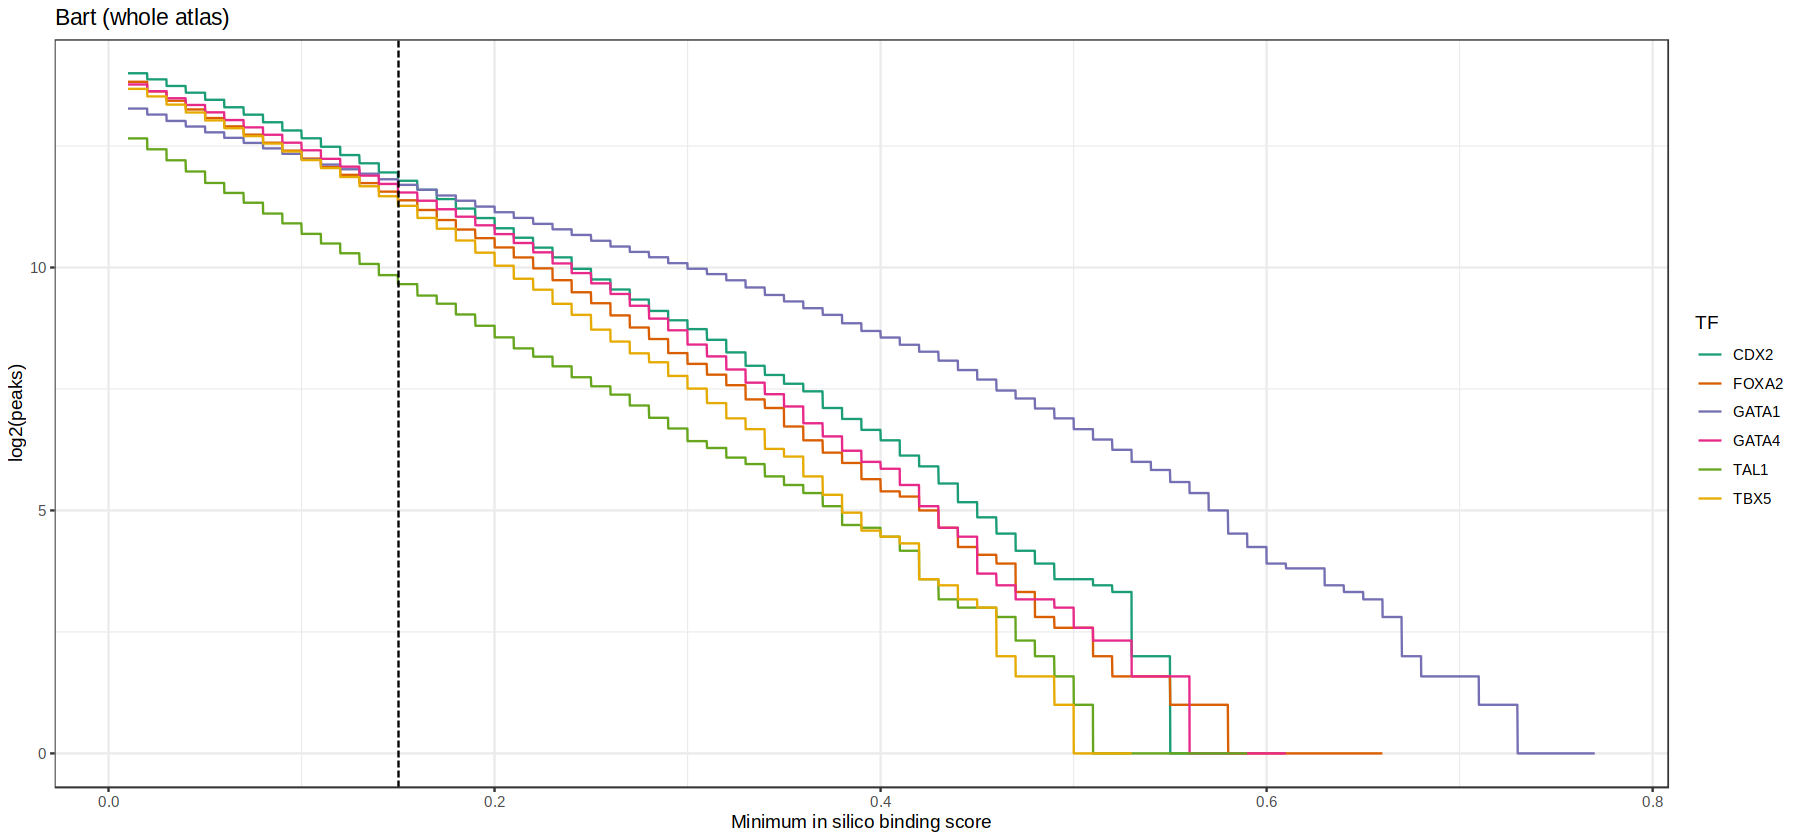

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 93645"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 93645"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 4404"
Running ChromVAR-ChIP-seq (ArchR implementation) 


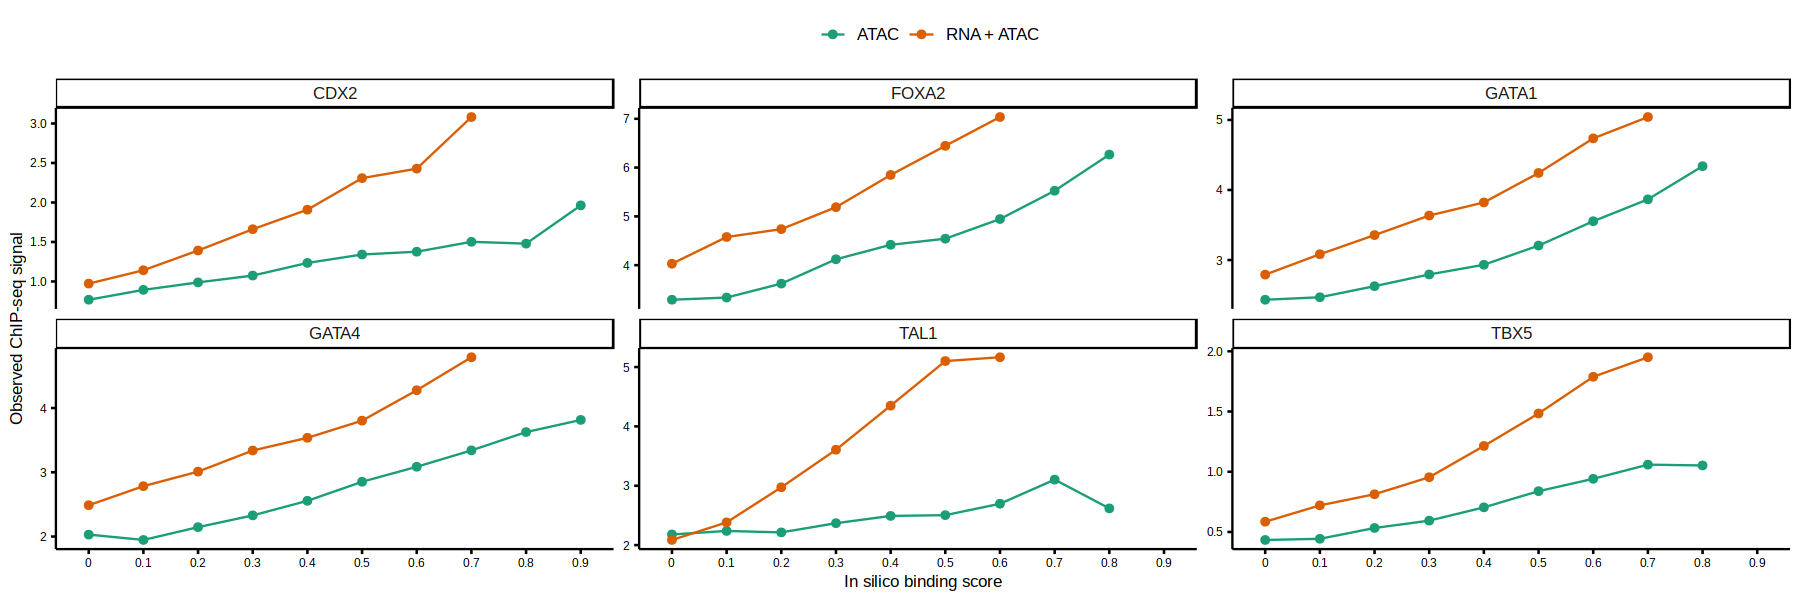

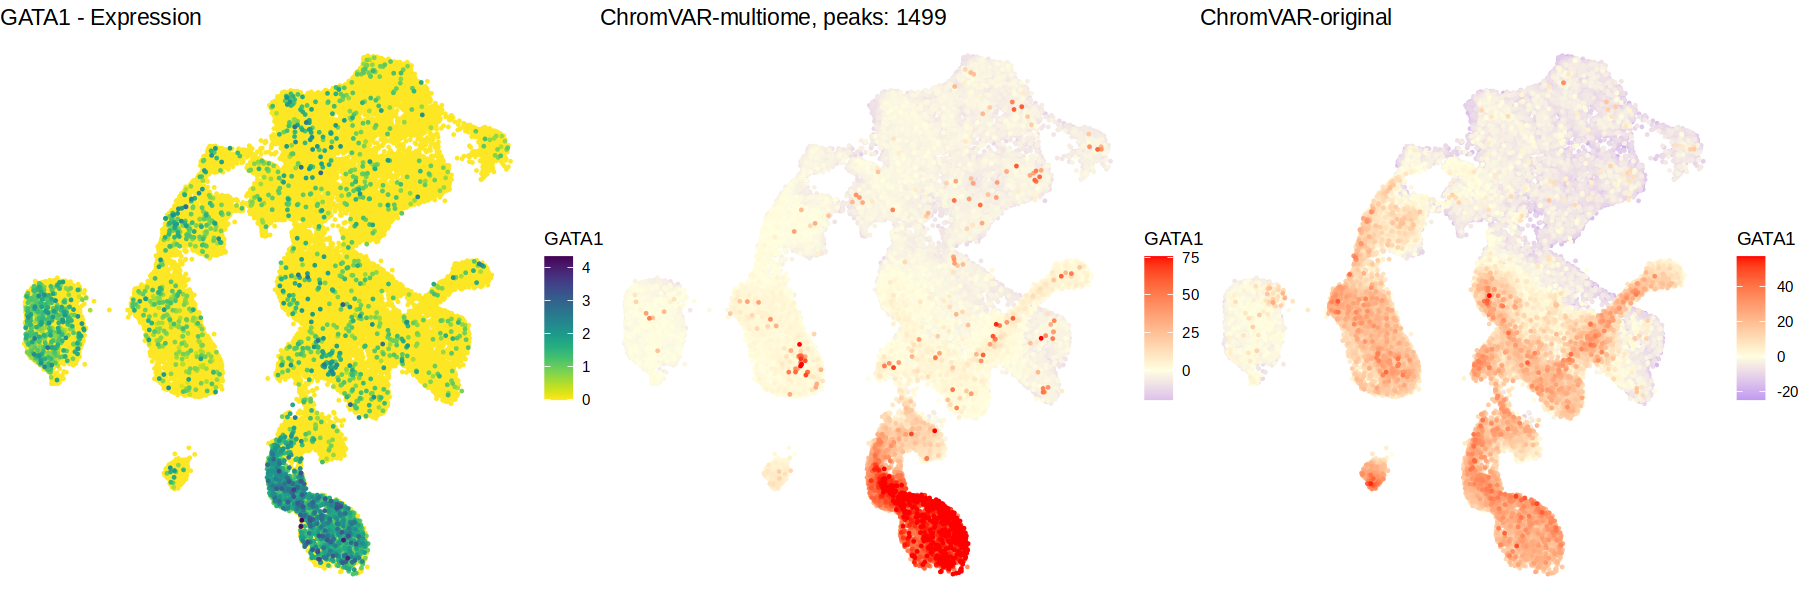

In [69]:
ATAC_subsample(0.01)

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


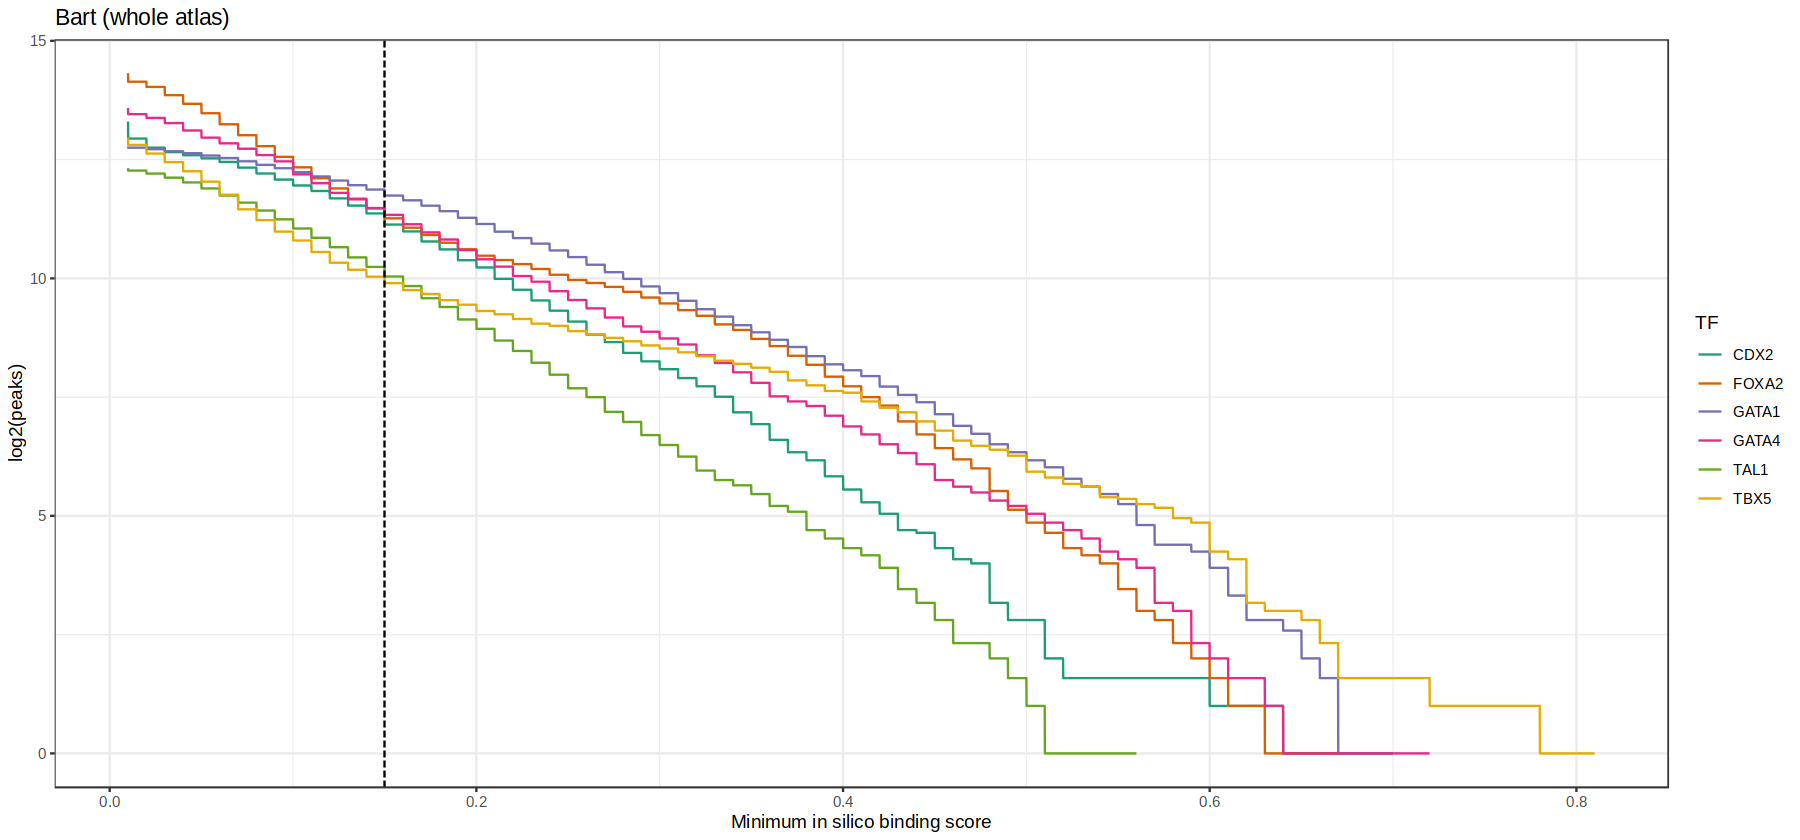

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 132263"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 132263"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 4368"
Running ChromVAR-ChIP-seq (ArchR implementation) 


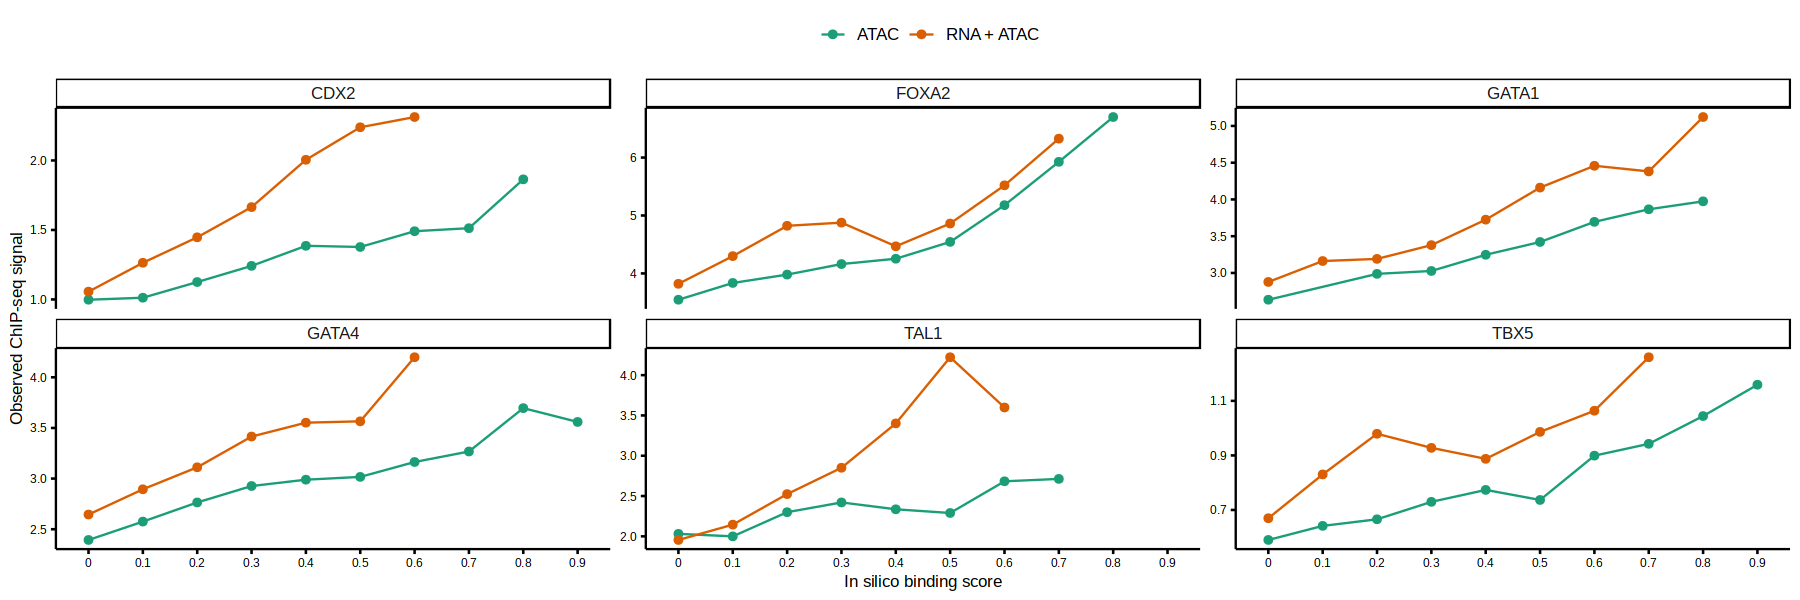

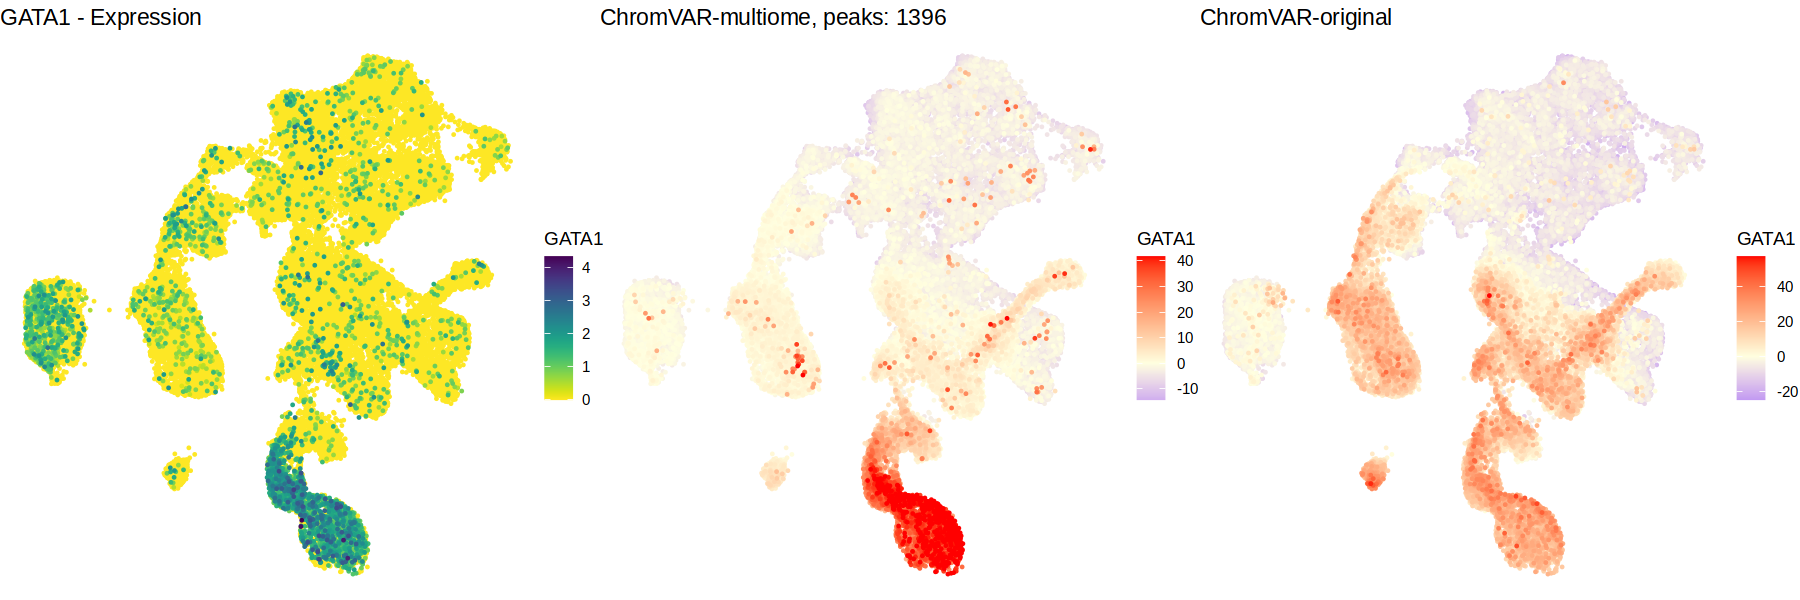

In [68]:
ATAC_subsample(0.001)

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


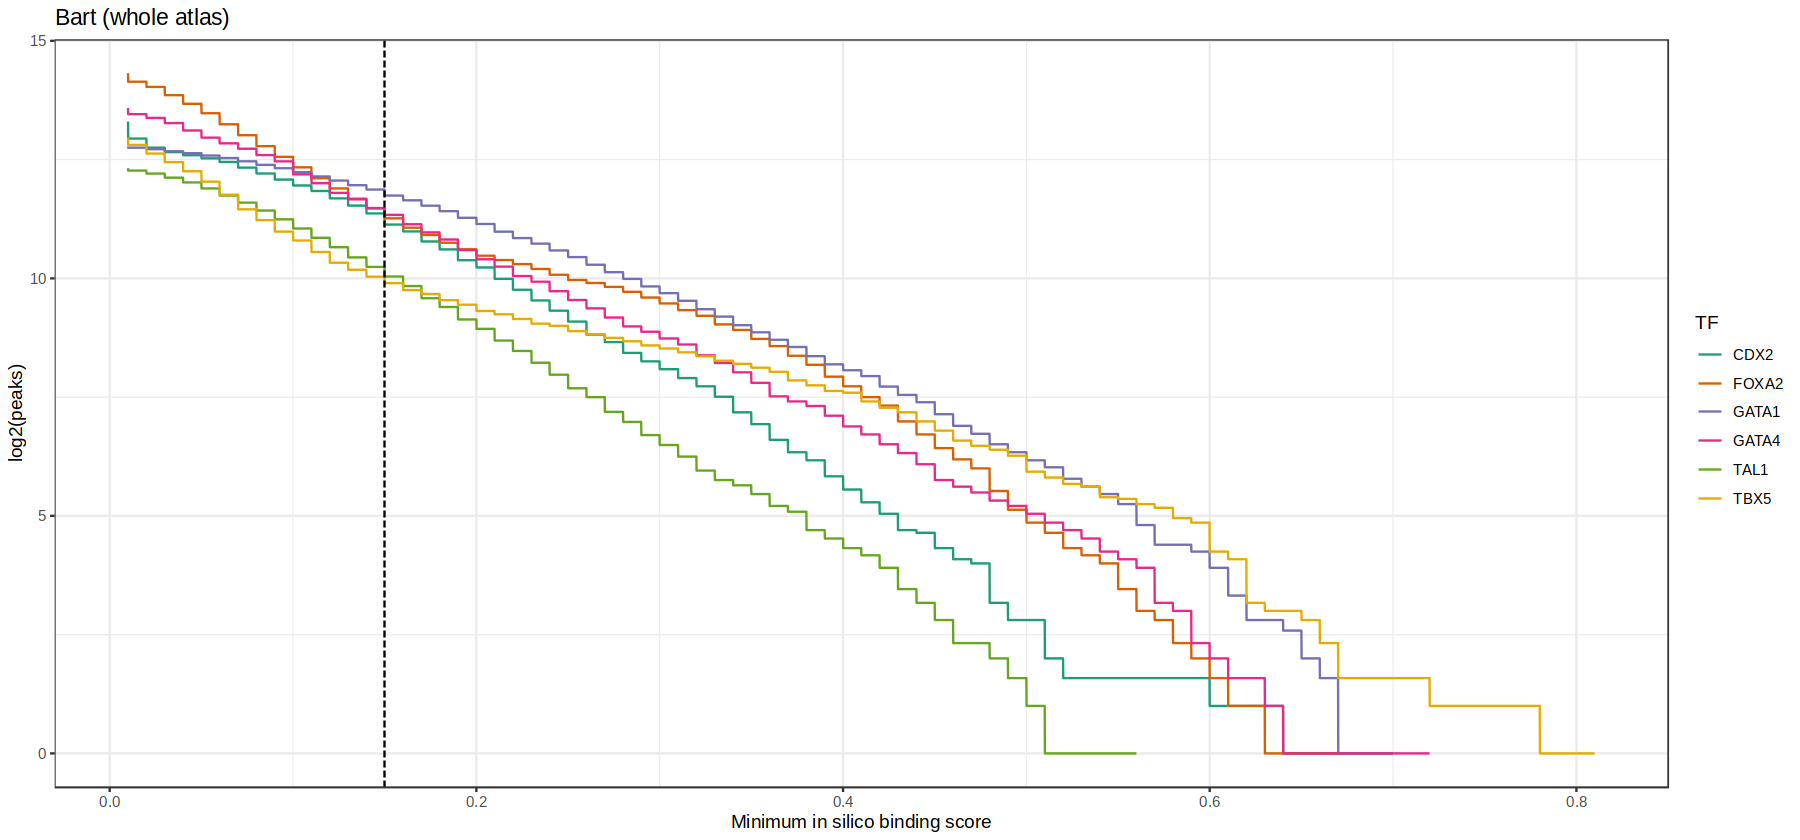

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 132263"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 132263"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 4368"
Running ChromVAR-ChIP-seq (ArchR implementation) 


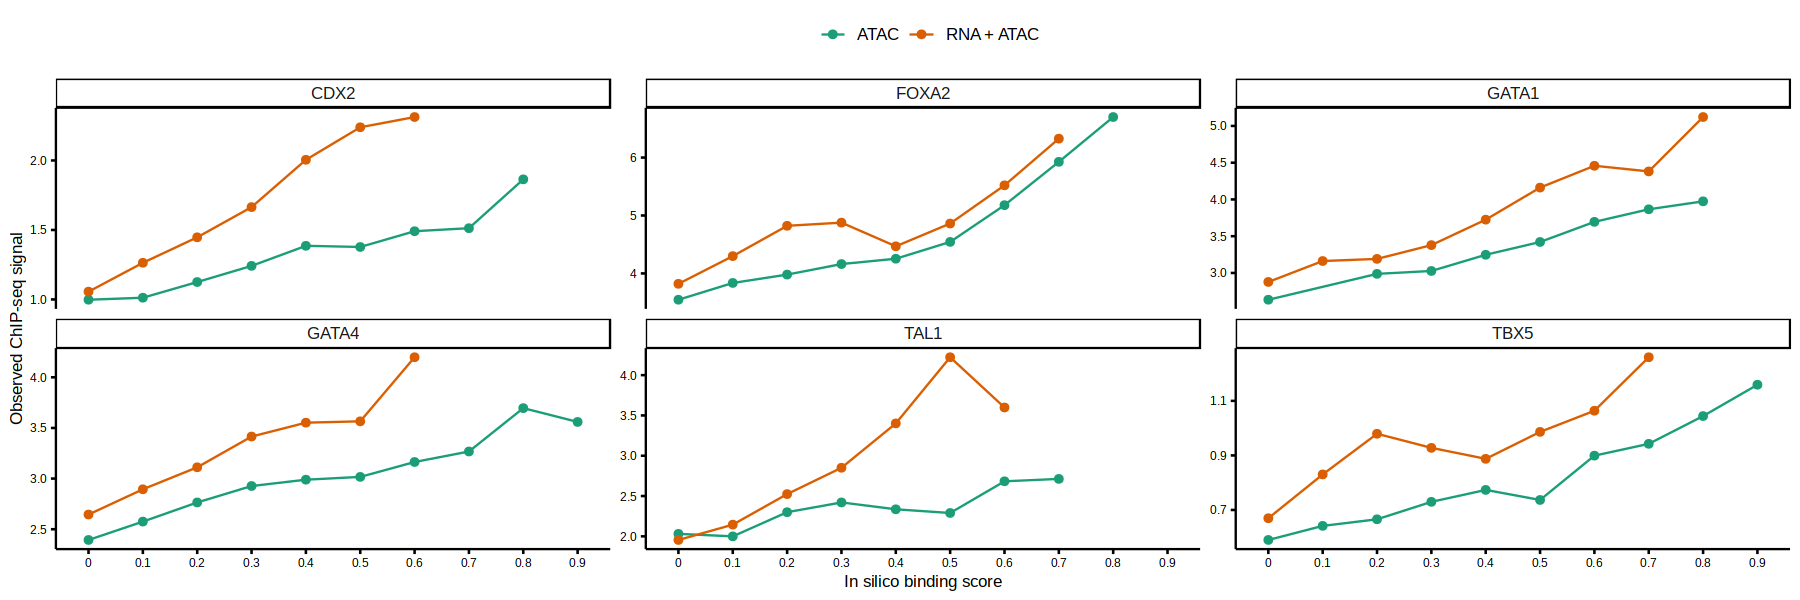

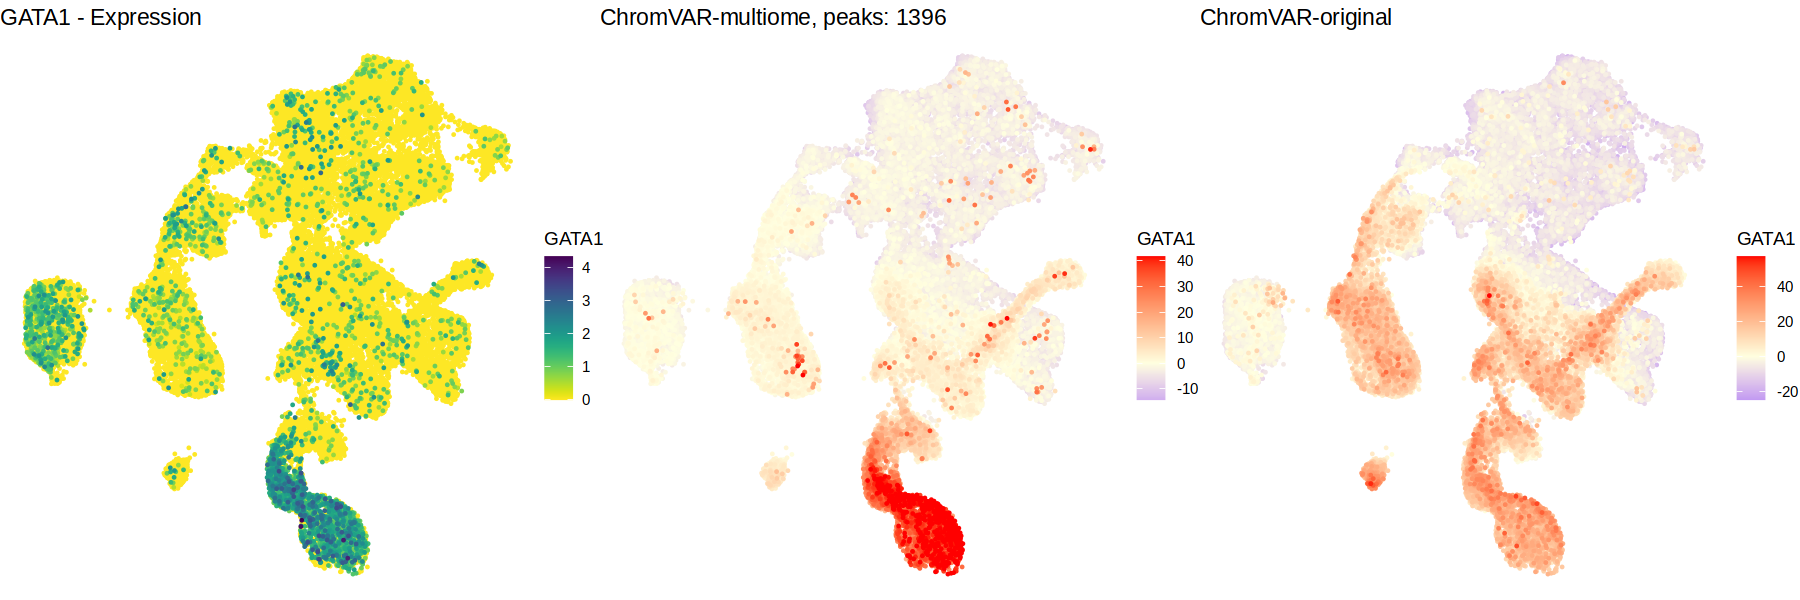

In [68]:
ATAC_subsample(0.001)

[1] "Pseudobulking RNA & ATAC"
[1] "ATAC statistics: "
[1] "TF peak correlation"
[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "In-silico ChIP"
[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


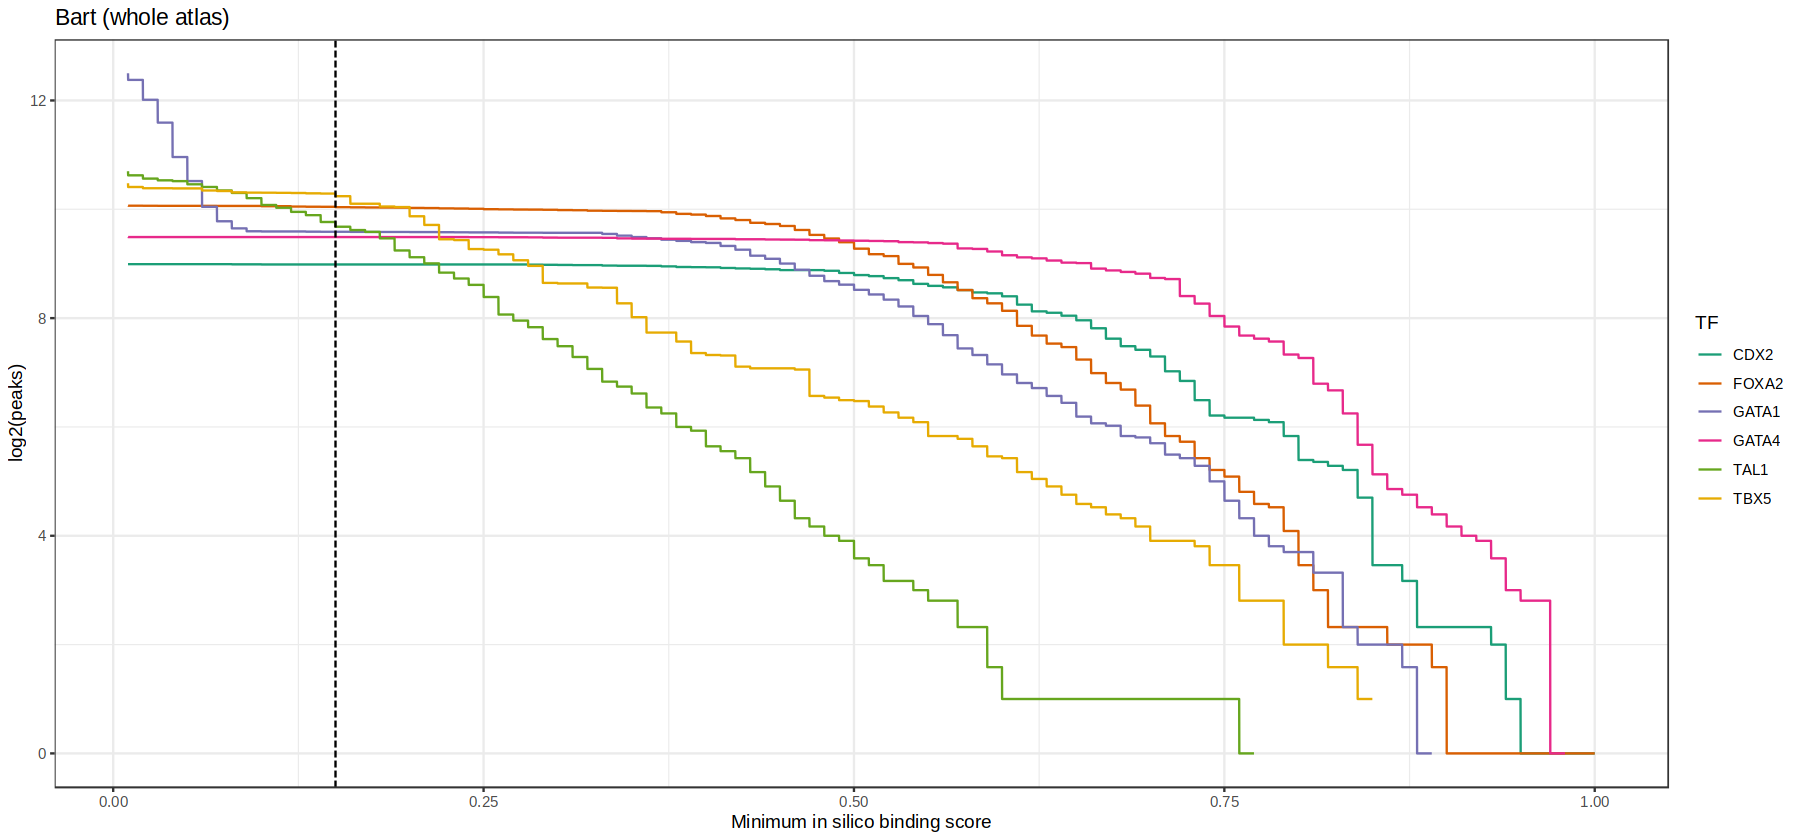

[1] "Number of matches before filtering negative TF binding values: 216019"
[1] "Number of matches after filtering negative TF binding values: 174066"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 174066"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 3960"
Running ChromVAR-ChIP-seq (ArchR implementation) 


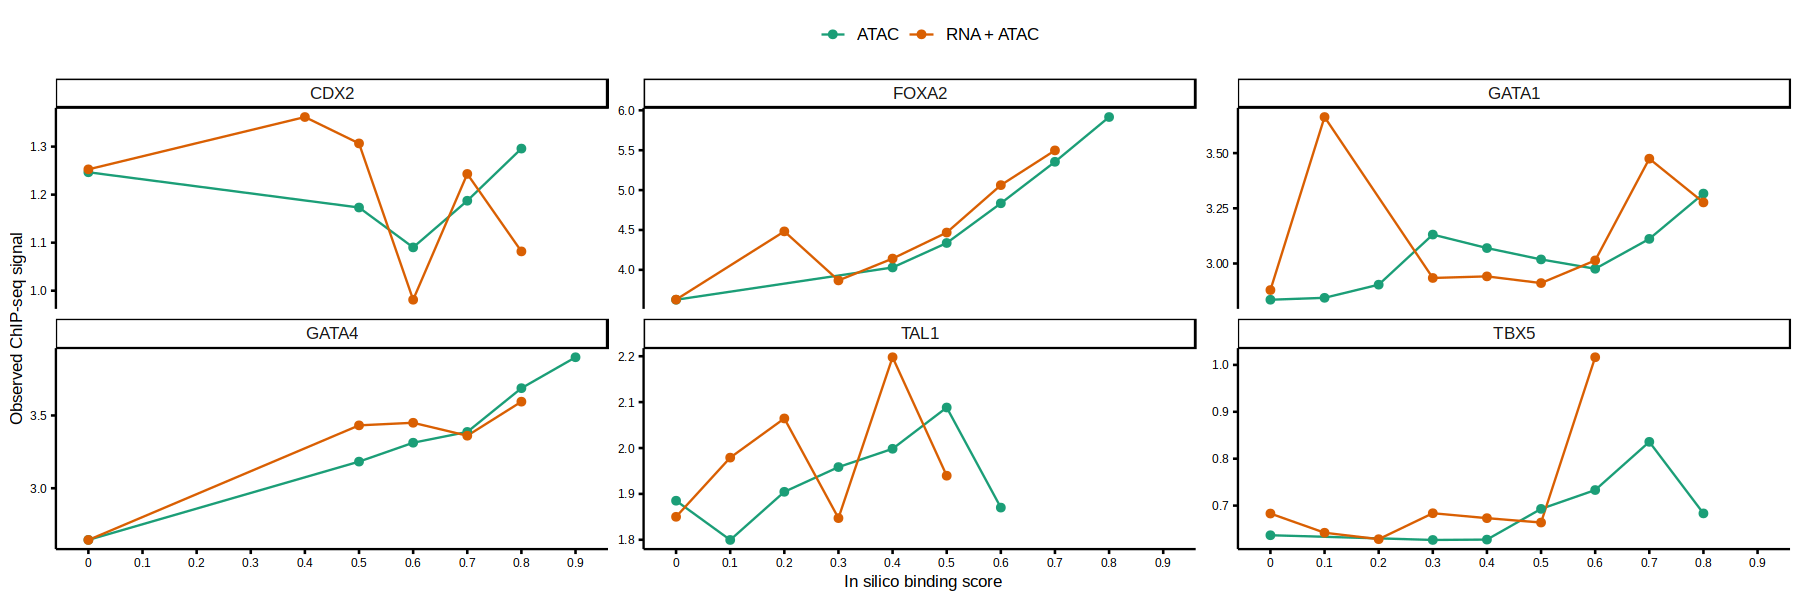

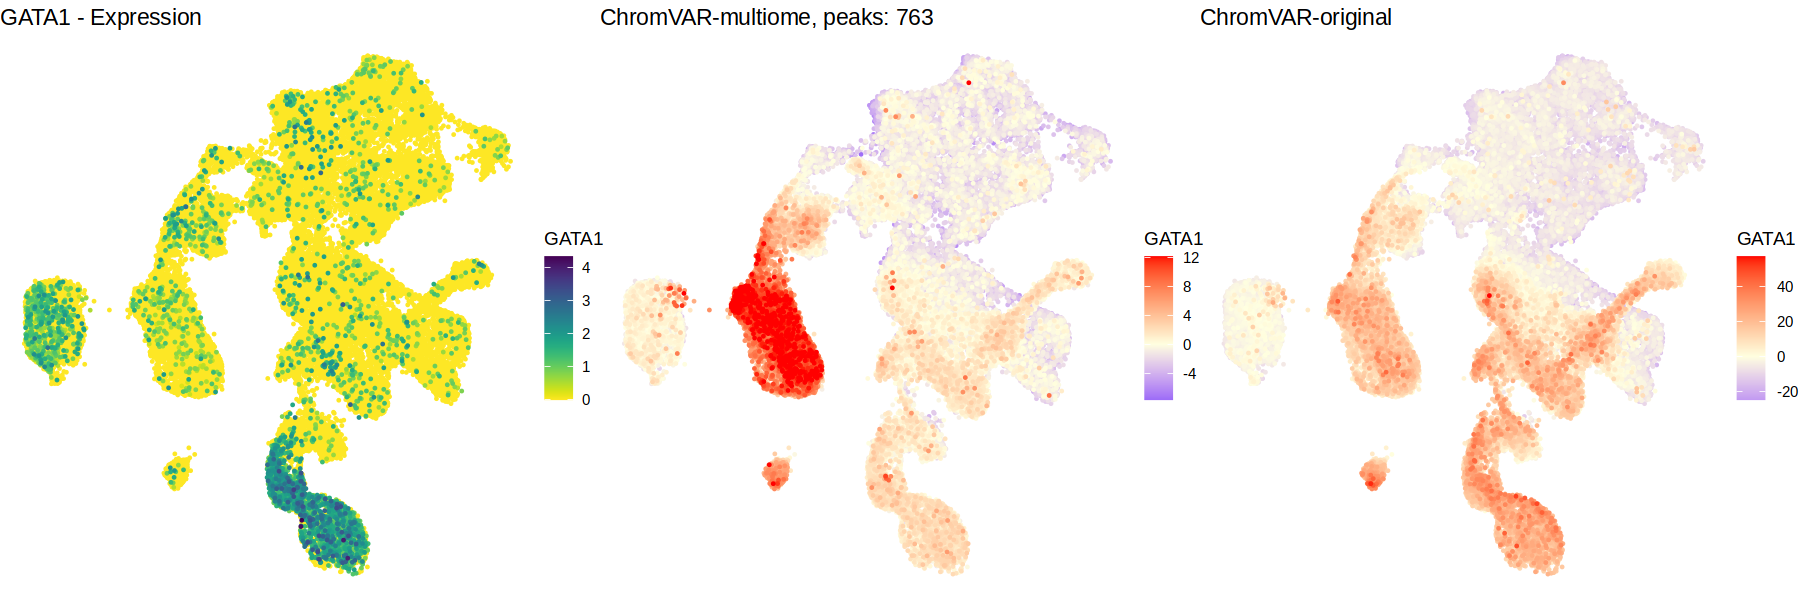

In [81]:
ATAC_subsample(0.0001)